# 24 - My synthesis of the results

I use this notebook to pull the main results into one place and check which conclusions are actually supported across the whole analysis. I am not fitting another model here. I read the CSV and JSON outputs from notebooks 00-23, print the values I want to carry forward, and record them in one findings ledger.

The question for this final pass is: **after testing topology, service volume, simulated closures, geography, socioeconomic context, communities, transport modes, travel time, time of day, population weighting, rerouting, and several definitions of criticality, what do I actually know?**

The main themes I want to keep straight are:

- service volume and structural importance identify mostly different stations;
- targeted removal is more damaging than random failure, but the effect depends on the normalization and removal scale;
- regional differences in top-betweenness share are small even when statistically significant;
- socioeconomic relationships are weak nationally and heterogeneous locally;
- rail and light rail have different topology from the bus-dominated national graph;
- hop-count, time of day, and population weighting all move the centrality ranking;
- machine-learning experiments do not show a clear embedding-specific advantage;
- the seven criticality lenses have low average agreement and very unequal coverage.

I save `stage_availability.csv`, `headline_findings.csv`, `operational_vs_structural_overlap.csv`, and two figures under `outputs/nb/24_conclusions/`. Every numerical statement in the code is read from a stage output so a partial rerun can skip missing sections instead of substituting a remembered value.

## 1. Set up the project paths

I locate the repository, switch into it, and create the shared notebook output directory. The package helper installs only missing dependencies and can clone the project in Colab. This notebook never reads the raw GTFS tables directly, but it still uses the common `REPO`, `DATA`, and `OUT` setup.

In [ ]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

## 2. Load the small analysis stack and create this stage

I only need pandas, NumPy, matplotlib, and Seaborn because the graph calculations are already complete. I create this notebook's `tables` and `figures` folders.

`OVERLAP_KS` sets the ranking depths used when I compare service volume with betweenness, `TOP_N` limits displayed rows, and `FIG_DPI` controls saved figure resolution.

In [2]:
# --- Libraries and stage folders ------------------------------------------
_ensure('pandas', 'numpy', 'matplotlib', 'seaborn', 'scipy')

import json
import math
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.05)

STAGE = OUT / '24_conclusions'      # everything this notebook produces
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Tunable constants ----------------------------------------------------
FIG_DPI = 150                      # figure resolution
TOP_N = 20                         # rows shown in illustrative tables
OVERLAP_KS = [10, 50, 100, 500]    # ranking depths for the agreement measurement
CRITICAL_QUANTILE = 0.90           # "critical" = top 10% betweenness (as in notebooks 05 and 07)

print('reading stages from :', OUT)
print('this stage          :', STAGE)

reading stages from : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb
this stage          : C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\24_conclusions


## 3. Prepare Hebrew labels for plotting

This matplotlib build already handles Hebrew direction correctly, so `fix_he` leaves text unchanged. I select a font with Hebrew glyphs, disable scientific-offset formatting, and remove any leftover text patch that could reverse labels twice.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# Pre-reordering with python-bidi would reverse it a second time, so fix_he stays a no-op
# and only a Hebrew-capable font is selected. A build without native bidi handling would
# need get_display; this build does not.
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # Remove any existing bidi patch so labels render in their raw logical order.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Define the stage registry and tolerant readers

I map each stage number to its expected folder and the notebook that creates it. `stage_dir` finds a folder by numeric prefix, while `stage_file`, `load_csv`, and `load_json` search recursively and return `None` with a message when an optional result is absent.

The rail loader also checks the read-only `outputs/rail` location if notebook 11's stage folder is unavailable. `get`, `jget`, `fmt`, and `pct` handle small schema differences and missing keys without turning a partial synthesis into an exception.

In [4]:
# --- Stage registry -------------------------------------------------------
STAGE_FOLDERS = {
    '00': '00_setup_and_data',
    '01': '01_data_preparation',
    '02': '02_graph_construction',
    '03': '03_descriptive_analysis',
    '04': '04_centrality_analysis',
    '05': '05_critical_station_isolation',
    '06': '06_robustness_analysis',
    '07': '07_regional_comparison',
    '09': '09_socioeconomic_equity',
    '08': '08_community_detection',
    '10': '10_network_model_comparison',
    '11': '11_rail_network_analysis',
    '12': '12_rail_socioeconomic',
    '13': '13_embeddings_link_prediction',
    '14': '14_multimodal_inventory',
    '15': '15_bus_network',
    '16': '16_lightrail_and_minor_modes',
    '17': '17_multimodal_transfer_hubs',
    '18': '18_travel_time_network',
    '19': '19_time_of_day_graphs',
    '20': '20_dynamic_resilience',
    '21': '21_demand_weighted_criticality',
    '22': '22_rerouting_model',
    '23': '23_critical_station_lenses',
}


def stage_dir(key):
    """Folder of stage `key` under outputs/nb, tolerating a renamed slug. None if absent."""
    if not OUT.is_dir():
        return None
    exact = OUT / STAGE_FOLDERS[key]
    if exact.is_dir():
        return exact
    for d in sorted(p for p in OUT.iterdir() if p.is_dir()):
        if d.name.startswith(key + '_'):
            return d
    return None


def stage_file(key, *patterns, root=None):
    """First file under a stage folder matching one of the glob patterns, else None."""
    base = root if root is not None else stage_dir(key)
    if base is None or not base.is_dir():
        return None
    for pat in patterns:
        direct = base / pat
        if direct.is_file():
            return direct
        hits = sorted(base.rglob(pat))
        if hits:
            return hits[0]
    return None


def load_csv(key, *patterns, root=None, quiet=False, **kwargs):
    """Read the first matching CSV of a stage; return None (with a message) if unavailable."""
    path = stage_file(key, *patterns, root=root)
    if path is None:
        if not quiet:
            print('  missing: ' + ' | '.join(patterns) + '  (stage ' + key + ')')
        return None
    try:
        df = pd.read_csv(path, encoding='utf-8-sig', **kwargs)
    except Exception as exc:
        print('  unreadable:', path, '->', exc)
        return None
    if not quiet:
        print('  loaded  :', path.relative_to(OUT) if OUT in path.parents else path,
              '(' + format(len(df), ',') + ' rows)')
    return df


def load_json(key, *patterns, root=None, quiet=False):
    """Read the first matching JSON of a stage; return None (with a message) if unavailable."""
    path = stage_file(key, *patterns, root=root)
    if path is None:
        if not quiet:
            print('  missing: ' + ' | '.join(patterns) + '  (stage ' + key + ')')
        return None
    try:
        with open(path, 'r', encoding='utf-8') as fh:
            payload = json.load(fh)
    except Exception as exc:
        print('  unreadable:', path, '->', exc)
        return None
    if not quiet:
        print('  loaded  :', path.relative_to(OUT) if OUT in path.parents else path)
    return payload


def rail_dir():
    """Stage 11 folder, or the read-only outputs/rail fallback."""
    d = stage_dir('11')
    if d is not None:
        return d
    fallback = REPO / 'outputs' / 'rail'
    if fallback.is_dir():
        print('  note: stage 11 not found; using the read-only outputs/rail fallback', fallback)
        return fallback
    return None


def get(container, *keys, default=None):
    """First present key of a dict / pandas Series, else `default`."""
    if container is None:
        return default
    for k in keys:
        if isinstance(container, dict):
            if k in container:
                return container[k]
        else:
            try:
                if k in container.index:
                    return container[k]
            except Exception:
                pass
    return default


def jget(payload, *path, default=None):
    """Walk a path through nested dicts (stage summary JSONs). Never raises."""
    cur = payload
    for key in path:
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def pick_col(df, *candidates):
    """First column name of `df` present in `candidates` (case-insensitive), else None."""
    if df is None:
        return None
    lower = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return None


def fmt(value, digits=3):
    """Print-safe number formatting: None / NaN / text never raise."""
    if value is None:
        return 'n/a'
    if isinstance(value, str):
        return value
    try:
        x = float(value)
    except (TypeError, ValueError):
        return str(value)
    if math.isnan(x):
        return 'n/a'
    if float(x).is_integer() and abs(x) >= 1:
        return format(int(x), ',')
    return format(x, ',.' + str(digits) + 'f')


def pct(value, digits=1):
    """Render a 0-1 share as a percentage string; never raises on None / NaN."""
    if value is None:
        return 'n/a'
    try:
        x = float(value)
    except (TypeError, ValueError):
        return 'n/a'
    if math.isnan(x):
        return 'n/a'
    return format(100.0 * x, ',.' + str(digits) + 'f') + '%'


print('registry ready:', len(STAGE_FOLDERS), 'upstream stages known.')


registry ready: 24 upstream stages known.


## 5. Audit the available stages first

I check all 24 upstream stage folders, count their tables and figures, record their modification time, and save the result to `stage_availability.csv`. The rest of the notebook uses the same tolerant loaders, so a missing stage produces a skipped section rather than a fabricated zero. In the embedded run, all 24 stages are present.

In [5]:
# --- Availability audit ---------------------------------------------------
import datetime

rows = []
for key, folder in STAGE_FOLDERS.items():
    d = stage_dir(key)
    if d is None:
        rows.append({'stage': key, 'expected_folder': folder, 'found_folder': '',
                     'present': False, 'n_tables': 0, 'n_figures': 0, 'last_modified': ''})
        continue
    tables = [p for p in d.rglob('*.csv')] + [p for p in d.rglob('*.json')]
    figures = [p for p in d.rglob('*.png')] + [p for p in d.rglob('*.svg')]
    files = [p for p in d.rglob('*') if p.is_file()]
    newest = max((p.stat().st_mtime for p in files), default=None)
    rows.append({
        'stage': key,
        'expected_folder': folder,
        'found_folder': d.name,
        # an empty folder means the stage started and failed - treat it as not run
        'present': len(files) > 0,
        'n_tables': len(tables),
        'n_figures': len(figures),
        'last_modified': ('' if newest is None else
                          datetime.datetime.fromtimestamp(newest).strftime('%Y-%m-%d %H:%M')),
    })

availability = pd.DataFrame(rows)
availability.to_csv(TABLES / 'stage_availability.csv', index=False, encoding='utf-8-sig')

present = availability[availability['present']]
absent = availability[~availability['present']]

print('stages present :', len(present), 'of', len(availability))
if len(absent):
    print()
    print('MISSING OR EMPTY - the matching sections below will be skipped:')
    for _, r in absent.iterrows():
        state = 'folder exists but is empty' if r['found_folder'] else 'no folder'
        print('   stage ' + r['stage'] + ' (' + state + ') -> run notebook '
              + r['expected_folder'])
else:
    print('all upstream stages found.')
print()
print('saved ->', TABLES / 'stage_availability.csv')
availability

stages present : 24 of 24
all upstream stages found.

saved -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\24_conclusions\tables\stage_availability.csv


,stage,expected_folder,found_folder,present,n_tables,n_figures,last_modified
0,00,00_setup_and_data,00_setup_and_data,True,5,3,2026-07-24 15:25
1,01,01_data_preparation,01_data_preparation,True,7,4,2026-07-24 15:23
2,02,02_graph_construction,02_graph_construction,True,4,2,2026-07-24 15:23
3,03,03_descriptive_analysis,03_descriptive_analysis,True,7,5,2026-07-24 15:23
4,04,04_centrality_analysis,04_centrality_analysis,True,8,9,2026-07-24 15:24
5,05,05_critical_station_isolation,05_critical_station_isolation,True,2,2,2026-07-24 15:24
6,06,06_robustness_analysis,06_robustness_analysis,True,4,3,2026-07-24 15:25
7,07,07_regional_comparison,07_regional_comparison,True,5,6,2026-07-24 15:26
8,09,09_socioeconomic_equity,09_socioeconomic_equity,True,9,6,2026-07-24 15:26
9,08,08_community_detection,08_community_detection,True,6,4,2026-07-24 15:26


## 6. Start one findings ledger

Every section calls `record` when it has a value worth keeping. Each entry stores the section, metric, formatted value, source file, and a short interpretation. At the end I turn this same list into `headline_findings.csv`, so the summary table and the printed sections come from one data path.

In [6]:
# --- The single ledger every section writes into --------------------------
FINDINGS = []


def record(stage, theme, metric, value, source, note=''):
    """Append one traceable result to the cross-stage summary table."""
    FINDINGS.append({
        'stage': stage,
        'theme': theme,
        'metric': metric,
        'value': value if isinstance(value, str) else fmt(value),
        'source_file': source,
        'note': note,
    })


def section_header(title):
    print('=' * 78)
    print(title)
    print('=' * 78)


print('ledger initialised.')

ledger initialised.


## 7. Establish the network scale

I load the graph-build and descriptive summaries plus the articulation-point and bridge tables. This cell gives the denominator for everything else: nodes, undirected edges, density, average degree, component count, largest-component share, cut vertices, and cut edges.

For this run the merged graph has 30,463 stations and 51,772 edges. It is sparse, but 99.26% of stations are in the largest component; 900 stations are articulation points and 971 edges are bridges.

In [7]:
# --- Scale of the network -------------------------------------------------
section_header('SCALE OF THE NETWORK (stages 00-03)')

feed = load_json('00', 'feed_manifest.json', quiet=True)
build = load_json('02', 'graph_build_summary.json')
desc = load_json('03', 'network_summary.json')
if desc is None:
    desc_csv = load_csv('03', 'network_summary.csv')
    desc = desc_csv.iloc[0] if desc_csv is not None and len(desc_csv) else None

ap_df = load_csv('03', 'articulation_points.csv', 'top_articulation_points.csv')
br_df = load_csv('03', 'bridges.csv', 'top_bridges.csv')

if desc is None and build is None:
    print('\nSKIPPED - neither stage 02 nor stage 03 has been run; no network summary is available.')
    N_NODES = None
else:
    N_NODES = get(desc, 'num_nodes', default=get(build, 'num_nodes'))
    N_EDGES = get(desc, 'num_edges_undirected', default=get(build, 'num_edges_undirected'))
    DENSITY = get(desc, 'density', default=get(build, 'density'))
    AVG_DEG = get(desc, 'avg_degree', default=get(build, 'avg_degree'))
    N_COMP = get(desc, 'num_connected_components', default=get(build, 'connected_components'))
    LCC_SHARE = get(desc, 'largest_component_share')
    if LCC_SHARE is None:
        lcc_nodes = get(desc, 'largest_component_nodes', default=get(build, 'largest_component_size'))
        LCC_SHARE = (float(lcc_nodes) / float(N_NODES)) if (lcc_nodes and N_NODES) else None
    N_AP = get(desc, 'num_articulation_points', default=(len(ap_df) if ap_df is not None else None))
    N_BR = get(desc, 'num_bridges', default=(len(br_df) if br_df is not None else None))

    print()
    print('stations (nodes)            :', fmt(N_NODES))
    print('segments (undirected edges) :', fmt(N_EDGES))
    print('density                     :', fmt(DENSITY, 6))
    print('average degree              :', fmt(AVG_DEG, 2))
    print('connected components        :', fmt(N_COMP))
    print('largest-component share     :',
          'n/a' if LCC_SHARE is None else format(100 * float(LCC_SHARE), '.2f') + '%')
    print('articulation points         :', fmt(N_AP),
          '' if (N_AP is None or not N_NODES) else
          '(' + format(100 * float(N_AP) / float(N_NODES), '.2f') + '% of stations)')
    print('bridges                     :', fmt(N_BR),
          '' if (N_BR is None or not N_EDGES) else
          '(' + format(100 * float(N_BR) / float(N_EDGES), '.2f') + '% of segments)')

    src = 'network_summary.json (03) / graph_build_summary.json (02)'
    record('02-03', 'scale', 'active stations', N_NODES, src)
    record('02-03', 'scale', 'undirected segments', N_EDGES, src)
    record('02-03', 'scale', 'density', fmt(DENSITY, 6), src)
    record('02-03', 'scale', 'average degree', fmt(AVG_DEG, 2), src)
    record('02-03', 'scale', 'largest-component share',
           'n/a' if LCC_SHARE is None else format(100 * float(LCC_SHARE), '.2f') + '%', src)
    record('03', 'structure', 'articulation points (cut vertices)', N_AP,
           'articulation_points.csv', 'stations whose removal disconnects the graph')
    record('03', 'structure', 'bridges (cut edges)', N_BR, 'bridges.csv',
           'segments whose removal disconnects the graph')

if feed is not None:
    print()
    print('feed manifest keys available from stage 00:', ', '.join(sorted(feed)[:12]))

SCALE OF THE NETWORK (stages 00-03)
  loaded  : 02_graph_construction\tables\graph_build_summary.json
  loaded  : 03_descriptive_analysis\network_summary.json
  loaded  : 03_descriptive_analysis\tables\articulation_points.csv (900 rows)
  loaded  : 03_descriptive_analysis\tables\bridges.csv (971 rows)

stations (nodes)            : 30,463
segments (undirected edges) : 51,772
density                     : 0.000112
average degree              : 3.40
connected components        : 12
largest-component share     : 99.26%
articulation points         : 900 (2.95% of stations)
bridges                     : 971 (1.88% of segments)

feed manifest keys available from stage 00: agencies, data_dir, feed_service_end, feed_service_start, feed_span_days, files, route_type_counts, routes, service_ids, stage, stop_times_rows, stops


## 8. Compare operational and structural importance

I define operational importance as weighted degree—the scheduled trip records touching a station—and structural importance as sampled betweenness or articulation status.

The cell loads notebook 04's station table and saved Spearman matrix, then calculates:

- weighted-degree versus betweenness Spearman rho;
- overlap between their top 10, 50, 100, and 500 stations;
- articulation-point counts inside the top 100 of each ranking;
- the top station tables for both measures;
- the two-seed stability check for sampled betweenness.

This is the cleanest test of whether protecting the busiest stations would also protect the stations carrying the graph's shortest-path structure.

In [8]:
# --- Operational vs structural criticality --------------------------------
section_header('FINDING 1 - OPERATIONAL vs STRUCTURAL CRITICALITY (stage 04)')

metrics = load_csv('04', 'stop_metrics.csv', dtype={'stop_id': str})
corr_matrix = load_csv('04', 'centrality_correlation_spearman.csv', index_col=0)
stability = load_csv('04', 'betweenness_stability.csv', quiet=True)

WD_COL = BT_COL = None
overlap_table = None
rho_wd_bt = None

if metrics is None:
    print('\nSKIPPED - stage 04 (centrality analysis) has not been run, so the central '
          'operational-vs-structural comparison cannot be made.')
else:
    WD_COL = pick_col(metrics, 'weighted_degree', 'weighted_degree_centrality')
    BT_COL = pick_col(metrics, 'approx_betweenness', 'betweenness', 'betweenness_centrality')
    DEG_COL = pick_col(metrics, 'degree')
    ID_COL = pick_col(metrics, 'stop_id')
    NAME_COL = pick_col(metrics, 'stop_name', 'label')

    if WD_COL is None or BT_COL is None or ID_COL is None:
        print('\nSKIPPED - stop_metrics.csv lacks a stop_id, weighted-degree or betweenness '
              'column. Found:', list(metrics.columns))
        WD_COL = BT_COL = None
    else:
        for c in (WD_COL, BT_COL) + ((DEG_COL,) if DEG_COL else ()):
            metrics[c] = pd.to_numeric(metrics[c], errors='coerce')
        work = metrics.dropna(subset=[WD_COL, BT_COL]).copy()

        # (1) rank correlation - prefer the matrix stage 04 already computed
        if corr_matrix is not None and WD_COL in corr_matrix.columns and BT_COL in corr_matrix.index:
            rho_wd_bt = float(corr_matrix.loc[BT_COL, WD_COL])
            rho_source = 'centrality_correlation_spearman.csv'
        else:
            rho_wd_bt = float(work[WD_COL].corr(work[BT_COL], method='spearman'))
            rho_source = 'stop_metrics.csv (recomputed here)'

        print()
        print('Spearman rho, weighted degree vs betweenness :',
              format(rho_wd_bt, '+.3f'), ' <-', rho_source)
        if corr_matrix is not None and DEG_COL and DEG_COL in corr_matrix.columns \
                and BT_COL in corr_matrix.index:
            print('Spearman rho, plain degree     vs betweenness :',
                  format(float(corr_matrix.loc[BT_COL, DEG_COL]), '+.3f'))

        # (2) top-K overlap between the two rankings
        rows = []
        for k in OVERLAP_KS:
            k_eff = min(k, len(work))
            top_wd = set(work.nlargest(k_eff, WD_COL)[ID_COL].astype(str))
            top_bt = set(work.nlargest(k_eff, BT_COL)[ID_COL].astype(str))
            shared = len(top_wd & top_bt)
            rows.append({'k': k_eff, 'shared_stations': shared,
                         'overlap_share': round(shared / k_eff, 4) if k_eff else np.nan})
        overlap_table = pd.DataFrame(rows)
        overlap_table.to_csv(TABLES / 'operational_vs_structural_overlap.csv',
                             index=False, encoding='utf-8-sig')
        print()
        print('Top-K overlap between the service ranking and the betweenness ranking:')
        print(overlap_table.to_string(index=False))
        print('saved ->', TABLES / 'operational_vs_structural_overlap.csv')

        # (3) how many of the busiest stations are proven cut vertices
        ap_overlap = None
        if ap_df is not None:
            ap_id = pick_col(ap_df, 'stop_id')
            if ap_id is not None:
                ap_ids = set(ap_df[ap_id].astype(str))
                k_eff = min(100, len(work))
                busiest = set(work.nlargest(k_eff, WD_COL)[ID_COL].astype(str))
                most_central = set(work.nlargest(k_eff, BT_COL)[ID_COL].astype(str))
                ap_overlap = (len(busiest & ap_ids), len(most_central & ap_ids), k_eff)
                print()
                print('Of the ' + str(k_eff) + ' busiest stations (weighted degree), '
                      + str(ap_overlap[0]) + ' are articulation points.')
                print('Of the ' + str(k_eff) + ' highest-betweenness stations,      '
                      + str(ap_overlap[1]) + ' are articulation points.')

        shallow = overlap_table[overlap_table['k'] <= 50]
        k50 = (shallow if len(shallow) else overlap_table).iloc[-1]
        record('04', 'operational vs structural', 'Spearman rho (weighted degree vs betweenness)',
               format(rho_wd_bt, '+.3f'), rho_source,
               'far below 1: the two rankings are not the same stations')
        record('04', 'operational vs structural',
               'top-' + str(int(k50['k'])) + ' overlap between the rankings',
               format(100 * float(k50['overlap_share']), '.1f') + '%',
               'stop_metrics.csv', 'share of the busiest stations that are also the most central')
        if ap_overlap is not None:
            record('04+03', 'operational vs structural',
                   'articulation points among the ' + str(ap_overlap[2]) + ' busiest stations',
                   ap_overlap[0], 'stop_metrics.csv + articulation_points.csv')

        # illustrative head-to-head table
        cols = [c for c in [ID_COL, NAME_COL, DEG_COL, WD_COL, BT_COL] if c]
        print()
        print('Top ' + str(TOP_N) + ' by service volume (operational):')
        display(work.nlargest(TOP_N, WD_COL)[cols].reset_index(drop=True))
        print('Top ' + str(TOP_N) + ' by betweenness (structural):')
        display(work.nlargest(TOP_N, BT_COL)[cols].reset_index(drop=True))

if stability is not None and len(stability):
    print()
    print('Sanity check on the betweenness estimate itself (stage 04, two random seeds):')
    print(stability.iloc[0].to_string())

FINDING 1 - OPERATIONAL vs STRUCTURAL CRITICALITY (stage 04)
  loaded  : 04_centrality_analysis\tables\stop_metrics.csv (30,463 rows)
  loaded  : 04_centrality_analysis\tables\centrality_correlation_spearman.csv (5 rows)

Spearman rho, weighted degree vs betweenness : +0.187  <- centrality_correlation_spearman.csv
Spearman rho, plain degree     vs betweenness : +0.514

Top-K overlap between the service ranking and the betweenness ranking:
  k  shared_stations  overlap_share
 10                0          0.000
 50                4          0.080
100               11          0.110
500               42          0.084
saved -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\24_conclusions\tables\operational_vs_structural_overlap.csv



Of the 100 busiest stations (weighted degree), 14 are articulation points.
Of the 100 highest-betweenness stations,      10 are articulation points.

Top 20 by service volume (operational):


,stop_id,stop_name,degree,weighted_degree,approx_betweenness
0,13103,קניון עזריאלי/דרך מנחם בגין,19,21396.0,0.000828
1,10775,גשר המיתרים/שד' הרצל,37,18976.0,0.016614
2,10716,צומת רמות/גולדה,40,17392.0,0.010077
3,12910,דרך נמיר/יהודה המכבי,10,16816.0,0.001347
4,13358,סמינר הקיבוצים/דרך נמיר,21,15780.0,0.002775
5,13120,דרך זאב ז'בוטינסקי/מכון מור,9,14786.0,0.000166
6,13206,קריית הממשלה/דרך מנחם בגין,10,14386.0,0.000063
7,10790,צומת רמות/גולדה,31,14154.0,0.013754
8,13067,דרך נמיר/יהודה המכבי,8,13648.0,0.000456
9,48363,ת.רק''ל יהודית/דרך מנחם בגין,8,13610.0,0.000178


Top 20 by betweenness (structural):


,stop_id,stop_name,degree,weighted_degree,approx_betweenness
0,17303,ת.התרעננות/דור אלון מגל 6,16,220.0,0.112460
1,41133,מחלף חמד,62,10454.0,0.087536
2,27689,מחלף קמה לצפון,24,1304.0,0.071648
3,7444,דרך האר''י/ כביש 375,29,5272.0,0.069171
4,41132,מחלף חמד,44,10540.0,0.066713
5,7562,שדרות בית הלל/כניסה לעיר,29,3870.0,0.065786
6,23418,רבי יהודה הנשיא/כניסה לעיר,24,1374.0,0.056599
7,748,מחלף קסם,19,1534.0,0.047273
8,29243,תחנת התרעננות/פונדק בית קמה,19,520.0,0.046289
9,18876,צומת חנניה צומת שבע,13,636.0,0.043864



Sanity check on the betweenness estimate itself (stage 04, two random seeds):
k_samples                   300.000000
lcc_nodes                 30237.000000
sampling_fraction             0.009922
spearman_all_nodes            0.956400
spearman_both_positive        0.941600
top10_overlap                 0.900000
top50_overlap                 0.840000
p90_flag_jaccard              0.529600
p90_flagged_seed_a         3024.000000
p90_flagged_seed_b         3024.000000


### Figure 1 - draw the service-versus-structure gap

The left panel scatters all stations by weighted degree and betweenness, using log-like axes that can still show zero betweenness. The right panel plots top-K overlap share against K with perfect agreement at 1.0. Both panels use the values calculated directly above and are skipped if the centrality stage is unavailable.

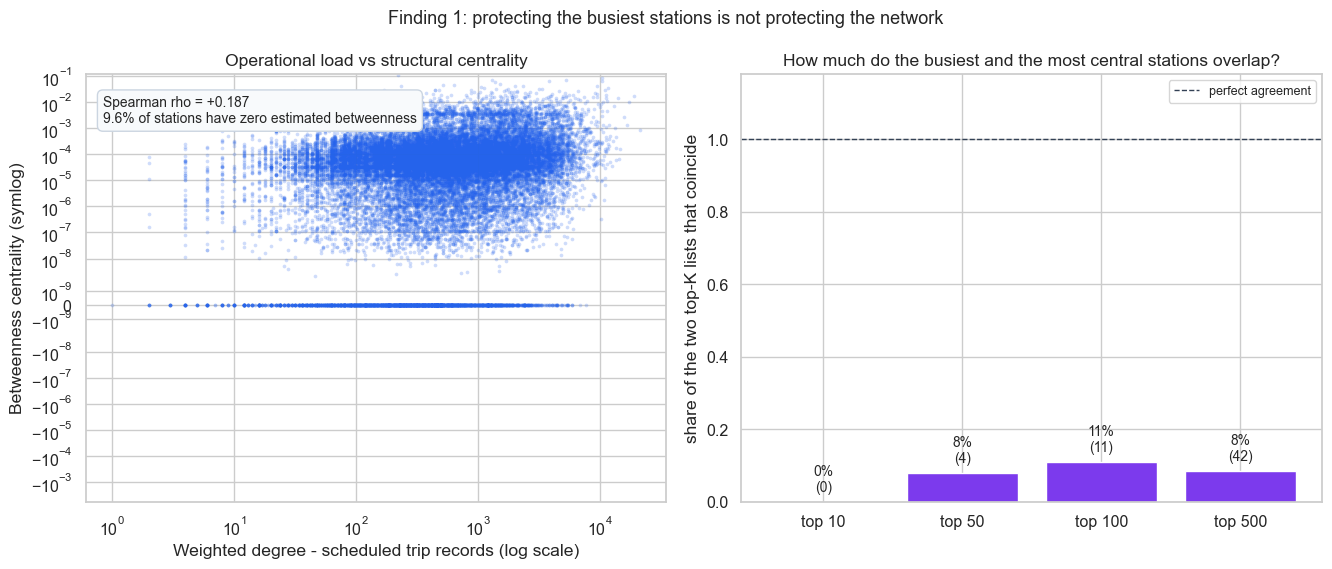

saved -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\24_conclusions\figures\operational_vs_structural.png


In [9]:
# --- Figure 1: operational vs structural criticality -----------------------
if metrics is None or WD_COL is None or BT_COL is None or overlap_table is None:
    print('SKIPPED - Figure 1 needs stage 04 stop_metrics.csv with weighted-degree '
          'and betweenness columns.')
else:
    d = metrics[[WD_COL, BT_COL]].apply(pd.to_numeric, errors='coerce').dropna()
    d = d[d[WD_COL] > 0]

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8))

    ax = axes[0]
    ax.scatter(d[WD_COL], d[BT_COL], s=7, alpha=0.22, color='#2563eb', linewidths=0)
    ax.set_xscale('log')
    positive = d[d[BT_COL] > 0][BT_COL]
    linthresh = float(positive.min()) if len(positive) else 1e-9
    ax.set_yscale('symlog', linthresh=max(linthresh, 1e-12))
    ax.set_xlabel('Weighted degree - scheduled trip records (log scale)')
    ax.set_ylabel('Betweenness centrality (symlog)')
    ax.set_title('Operational load vs structural centrality')
    ax.text(0.03, 0.95,
            'Spearman rho = ' + format(rho_wd_bt, '+.3f') + '\n'
            + format(100 * float((d[BT_COL] <= 0).mean()), '.1f')
            + '% of stations have zero estimated betweenness',
            transform=ax.transAxes, va='top', ha='left', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', fc='#f8fafc', ec='#cbd5e1'))

    ax = axes[1]
    labels = ['top ' + format(int(k), ',') for k in overlap_table['k']]
    bars = ax.bar(labels, overlap_table['overlap_share'], color='#7c3aed', edgecolor='white')
    for bar, share, shared in zip(bars, overlap_table['overlap_share'],
                                  overlap_table['shared_stations']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                format(100 * float(share), '.0f') + '%\n(' + format(int(shared), ',') + ')',
                ha='center', va='bottom', fontsize=10)
    ax.axhline(1.0, color='#334155', ls='--', lw=1.0, label='perfect agreement')
    ax.set_ylim(0, 1.18)
    ax.set_ylabel('share of the two top-K lists that coincide')
    ax.set_title('How much do the busiest and the most central stations overlap?')
    ax.legend(loc='upper right', fontsize=9)

    fig.suptitle('Finding 1: protecting the busiest stations is not protecting the network',
                 fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGURES / 'operational_vs_structural.png', dpi=FIG_DPI, bbox_inches='tight')
    plt.show()
    print('saved ->', FIGURES / 'operational_vs_structural.png')

## 9. Check whether top-betweenness stations have a nearby substitute

I load notebook 05's distance-band summary and station-level isolation table. The calculation covers the 3,047 stations in the network-wide top betweenness decile and asks how far each is from another stop.

The current result is mostly substitutable by this narrow spatial definition: 2,991 stations are within 300 m and 56 (1.8%) are farther away. I keep the highest-betweenness isolated examples, but I do not treat a nearby stop as a functional substitute unless its routes and hours are also checked.

In [10]:
# --- Substitutability of critical stations --------------------------------
section_header('FINDING 2 - DO CRITICAL STATIONS HAVE A SUBSTITUTE? (stage 05)')

iso_summary = load_csv('05', 'isolation_summary.csv')
iso_detail = load_csv('05', 'critical_isolation.csv', dtype={'stop_id': str}, quiet=True)

if iso_summary is None:
    print('\nSKIPPED - stage 05 (critical-station isolation) has not been run.')
else:
    band_col = pick_col(iso_summary, 'distance_band')
    n_col = pick_col(iso_summary, 'n_critical_stops', 'n_stops', 'count')
    verdict_col = pick_col(iso_summary, 'verdict')
    total_critical = int(pd.to_numeric(iso_summary[n_col], errors='coerce').fillna(0).sum())

    print()
    print(iso_summary.to_string(index=False))
    print()
    print('critical stations examined :', format(total_critical, ','))

    if verdict_col is not None and total_critical:
        isolated_n = int(pd.to_numeric(
            iso_summary.loc[iso_summary[verdict_col].astype(str).str.contains('isolat', case=False),
                            n_col], errors='coerce').fillna(0).sum())
        print('no other graph stop within 300 m:', format(isolated_n, ','),
              '(' + format(100 * isolated_n / total_critical, '.1f') + '% of critical stations)')
        record('05', 'substitutability', 'critical stations examined (top 10% betweenness)',
               total_critical, 'isolation_summary.csv')
        record('05', 'substitutability',
               'critical stations with no other graph stop within 300 m',
               format(100 * isolated_n / total_critical, '.1f') + '%', 'isolation_summary.csv',
               'spatial proximity only - service substitutability is not tested')

    if iso_detail is not None:
        bt = pick_col(iso_detail, 'betweenness', 'approx_betweenness')
        dist = pick_col(iso_detail, 'nearest_alt_m')
        name = pick_col(iso_detail, 'stop_name')
        flag = pick_col(iso_detail, 'is_isolated')
        cols = [c for c in [pick_col(iso_detail, 'stop_id'), name, bt, dist] if c]
        if flag is not None:
            worst = iso_detail[iso_detail[flag].astype(str).str.lower().isin(['true', '1'])]
        else:
            worst = iso_detail
        if len(worst) and bt:
            print()
            print('Highest-betweenness isolated stations:')
            display(worst.sort_values(bt, ascending=False)[cols].head(TOP_N).reset_index(drop=True))

FINDING 2 - DO CRITICAL STATIONS HAVE A SUBSTITUTE? (stage 05)
  loaded  : 05_critical_station_isolation\tables\isolation_summary.csv (5 rows)

distance_band  n_critical_stops  share_pct       verdict
      < 100 m              1749      57.40 substitutable
    100-300 m              1242      40.76 substitutable
    300-500 m                35       1.15      isolated
   500-1000 m                12       0.39      isolated
       > 1 km                 9       0.30      isolated

critical stations examined : 3,047
no other graph stop within 300 m: 56 (1.8% of critical stations)

Highest-betweenness isolated stations:


,stop_id,stop_name,betweenness,nearest_alt_m
0,20408,מסעף קיבוץ קדרים לצפון,0.019430,427.667293
1,42405,תחנת התרעננות/צומת מגידו,0.015267,354.198699
2,23543,יסודות/מזכירות,0.007867,593.642770
3,35118,מרכז קלור/כפר בלום,0.007047,385.502606
4,20384,צומת יזרעאל,0.006340,327.711867
5,40662,קניון דרורים,0.005738,437.415711
6,20219,מסעף גדידה,0.005697,486.928104
7,20409,מסעף קיבוץ קדרים לדרום,0.005444,427.667293
8,27934,גבולות מרכז,0.005255,4189.103726
9,51208,תחנת התרעננות/נווה זוהר,0.004236,654.487242


## 10. Compare targeted removal with random failure

I read notebook 06's resilience AUC, damage snapshots, and full removal curves. The main comparison uses `lcc_share_surviving`, which divides the largest component by stations still present and therefore measures fragmentation rather than the mechanical loss of removed nodes.

I identify the lowest-AUC targeted strategy, compare it with the random baseline, and print the network state after 50 removals. I retain the original-denominator column for reference inside the table, but I do not use it as a fragmentation measure.

In [11]:
# --- Resilience under attack ----------------------------------------------
section_header('FINDING 3 - TARGETED ATTACK vs RANDOM FAILURE (stage 06)')

auc_df = load_csv('06', 'auc_summary.csv')
snapshots = load_csv('06', 'damage_snapshots.csv')
disruption = load_csv('06', 'disruption_results.csv')

if auc_df is None and disruption is None:
    print('\nSKIPPED - stage 06 (robustness analysis) has not been run.')
else:
    if auc_df is not None:
        print()
        print('Area under the resilience curve (lower = the attack does more damage):')
        print(auc_df.to_string(index=False))

        strat_col = pick_col(auc_df, 'strategy')
        surv_col = pick_col(auc_df, 'auc_surviving')
        orig_col = pick_col(auc_df, 'auc_original')
        if strat_col and surv_col:
            random_mask = auc_df[strat_col].astype(str).str.contains('random', case=False)
            targeted = auc_df[~random_mask]
            if len(targeted):
                worst = targeted.loc[pd.to_numeric(targeted[surv_col],
                                                   errors='coerce').idxmin()]
                print()
                print('most damaging targeted strategy :', worst[strat_col],
                      '(AUC surviving-normalised =', fmt(worst[surv_col], 4) + ')')
                record('06', 'resilience', 'most damaging attack strategy',
                       str(worst[strat_col]), 'auc_summary.csv',
                       'ranked by area under the surviving-normalised resilience curve')
                record('06', 'resilience', 'AUC of the most damaging targeted attack',
                       fmt(worst[surv_col], 4), 'auc_summary.csv',
                       'mean largest-component share among surviving stations')
            if random_mask.any():
                rnd = auc_df[random_mask].iloc[0]
                print('random-failure baseline         : AUC surviving-normalised =',
                      fmt(rnd[surv_col], 4))
                record('06', 'resilience', 'AUC of the random-failure baseline',
                       fmt(rnd[surv_col], 4), 'auc_summary.csv',
                       'the gap to the targeted attack is the robust-yet-fragile signature')
                if len(targeted):
                    gap = float(rnd[surv_col]) - float(worst[surv_col])
                    print('gap (random - worst targeted)   :', format(gap, '.4f'))
                    record('06', 'resilience', 'targeted-vs-random AUC gap',
                           format(gap, '.4f'), 'auc_summary.csv',
                           'positive = targeted removal hurts more than random failure')
            if orig_col:
                print()
                print('NOTE: the original-normalised AUC divides by the original station count and '
                      'therefore falls even when nothing fragments. I use the surviving-normalised '
                      'column as the fragmentation measure.')

    if snapshots is not None and len(snapshots):
        rem_col = pick_col(snapshots, 'removed')
        if rem_col:
            smallest_k = int(pd.to_numeric(snapshots[rem_col], errors='coerce').min())
            view = snapshots[pd.to_numeric(snapshots[rem_col], errors='coerce') == smallest_k]
            print()
            print('State after removing only ' + format(smallest_k, ',') + ' stations:')
            print(view.to_string(index=False))
            surv = pick_col(view, 'lcc_share_surviving')
            strat = pick_col(view, 'strategy')
            if surv and strat and len(view):
                v = view.loc[pd.to_numeric(view[surv], errors='coerce').idxmin()]
                record('06', 'resilience',
                       'worst largest-component share after removing '
                       + format(smallest_k, ',') + ' stations',
                       fmt(v[surv], 4), 'damage_snapshots.csv',
                       'strategy: ' + str(v[strat]) + '; normalised by surviving stations')

FINDING 3 - TARGETED ATTACK vs RANDOM FAILURE (stage 06)
  loaded  : 06_robustness_analysis\tables\auc_summary.csv (6 rows)
  loaded  : 06_robustness_analysis\tables\damage_snapshots.csv (12 rows)
  loaded  : 06_robustness_analysis\tables\disruption_results.csv (264 rows)

Area under the resilience curve (lower = the attack does more damage):
           strategy  auc_original  auc_surviving  rank_most_damaging
             degree        0.7340         0.7655                   1
        betweenness        0.7564         0.7895                   2
articulation points        0.8546         0.8964                   3
    weighted degree        0.9122         0.9587                   4
           pagerank        0.9129         0.9594                   5
  random (baseline)        0.9283         0.9760                   6

most damaging targeted strategy : degree (AUC surviving-normalised = 0.7655)
random-failure baseline         : AUC surviving-normalised = 0.9760
gap (random - worst target

## 11. Measure the regional effect size

I load the regional summary and chi-square result from notebook 07. I print the critical-station shares, articulation shares, bridge rates, the highest and lowest regions, Cramer's V, the percentage-point spread, and the metro table.

The p-value answers whether the rates are exactly equal. With 30,463 stations, I care more about Cramer's V and the 2.64-point spread when judging whether geography has a practically large association.

In [12]:
# --- Regional comparison --------------------------------------------------
section_header('FINDING 4 - REGIONAL DIFFERENCES (stage 07)')

regional = load_csv('07', 'regional_summary.csv')
regional_sig = load_csv('07', 'regional_significance.csv')
metro = load_csv('07', 'metro_summary.csv', quiet=True)

if regional is None:
    print('\nSKIPPED - stage 07 (regional comparison) has not been run.')
else:
    print()
    print(regional.to_string(index=False))

    reg_col = pick_col(regional, 'region', 'group')
    pct_col = pick_col(regional, 'pct_critical')
    small_col = pick_col(regional, 'small_sample')
    if pct_col and reg_col and pd.to_numeric(regional[pct_col], errors='coerce').notna().any():
        pct_series = pd.to_numeric(regional[pct_col], errors='coerce')
        hi = regional.loc[pct_series.idxmax()]
        lo = regional.loc[pct_series.idxmin()]
        print()
        print('highest share of critical stops :', str(hi[reg_col]),
              format(float(hi[pct_col]), '.2f') + '%')
        print('lowest  share of critical stops :', str(lo[reg_col]),
              format(float(lo[pct_col]), '.2f') + '%')
        record('07', 'regional', 'region with the highest share of critical stops',
               str(hi[reg_col]) + ' (' + format(float(hi[pct_col]), '.2f') + '%)',
               'regional_summary.csv')
        record('07', 'regional', 'spread between the extreme regions',
               format(float(pct_series.max() - pct_series.min()), '.2f') + ' pp', 'regional_summary.csv')
    if small_col is not None and reg_col and pct_col:
        flagged = regional[regional[small_col].astype(str).str.lower().isin(['true', '1'])]
        if len(flagged):
            print()
            print('small-sample groups flagged by stage 07 - I treat their percentages as unstable:')
            print(flagged[[reg_col, pct_col]].to_string(index=False))

    if regional_sig is not None and len(regional_sig):
        row = regional_sig.iloc[0]
        p_val = get(row, 'p_value')
        v = get(row, 'cramers_v')
        print()
        print('chi-square test of independence (region x is_critical):')
        print(row.to_string())
        if v is not None:
            strength = ('negligible' if float(v) < 0.1 else 'small' if float(v) < 0.3
                        else 'moderate' if float(v) < 0.5 else 'large')
            print()
            print("Cramer's V =", fmt(v, 4), '->', strength, 'association.')
            p_text = format(float(p_val), '.3g') if p_val is not None else 'n/a'
            print('p =', p_text,
                  '- with n = 30,463, even a very small association is statistically '
                  'detectable; effect size matters more here.')
            record('07', 'regional', "Cramer's V (region x criticality)",
                   fmt(v, 4) + ' (' + strength + ')', 'regional_significance.csv',
                   'p = ' + p_text + '; substantively ' + strength)

    if metro is not None:
        print()
        print('Metropolitan areas:')
        print(metro.to_string(index=False))

FINDING 4 - REGIONAL DIFFERENCES (stage 07)
  loaded  : 07_regional_comparison\tables\regional_summary.csv (4 rows)
  loaded  : 07_regional_comparison\tables\regional_significance.csv (1 rows)

   region  total_stops  critical_stops  critical_broad_stops  ap_stops  avg_degree  avg_betweenness  max_betweenness  pct_critical  pct_critical_broad  pct_ap  share_of_all_critical  share_of_all_stops  pct_critical_lo  pct_critical_hi  small_sample  bridges_touching  bridges_per_1000_stops
    North        10025            1158                  1399       273       3.161         0.000490         0.043864         11.55               13.96    2.72                   38.0                32.9            10.94            12.19         False               275                   27.43
Jerusalem         3743             383                   573       211       3.450         0.000444         0.087536         10.23               15.31    5.64                   12.6                12.3             9.30    

## 12. Keep national and within-community socioeconomic results separate

I read notebook 09's summary, within-community table, and national metric table. The sign convention stays raw: negative rho means more scheduled stop calls per resident in weaker-cluster areas.

I print the national neighborhood correlation, the community-level aggregate, the range of within-community correlations, and the counts surviving raw, BH, and Bonferroni thresholds. I treat this as heterogeneous local structure hidden by aggregation, not as one universal sign reversal: the 57 local estimates span `-0.691` to `+0.431`, and only eight survive BH correction.

In [13]:
# --- Socio-economic equity ------------------------------------------------
section_header('FINDING 5 - SOCIO-ECONOMIC EQUITY (stage 09)')

socio = load_json('09', 'socioeconomic_summary.json')
within = load_csv('09', 'socioeconomic_within_cluster_correlation.csv', quiet=True)
national_corr = load_csv('09', 'socioeconomic_national_correlations.csv', quiet=True)

if socio is None:
    print('\nSKIPPED - stage 09 (socio-economic equity) has not been run.')
else:
    print()
    print('sign convention  :', get(socio, 'sign_convention', default='n/a'))
    print('service variable :', get(socio, 'service_variable', default='n/a'))
    print()

    nat_rho = get(socio, 'national_neighborhood_rho')
    nat_p = get(socio, 'national_neighborhood_p')
    nat_n = get(socio, 'national_neighborhood_n')
    com_rho = get(socio, 'community_level_rho')
    com_p = get(socio, 'community_level_p')
    com_n = get(socio, 'community_level_n')
    rho_min = get(socio, 'within_rho_min')
    rho_max = get(socio, 'within_rho_max')
    n_tests = get(socio, 'communities_tested')
    sig_raw = get(socio, 'significant_raw')
    sig_fdr = get(socio, 'significant_fdr_bh')
    sig_bonf = get(socio, 'significant_bonferroni')

    print('national, neighbourhood level : rho =', fmt(nat_rho, 3),
          ' p =', fmt(nat_p, 6), ' n =', fmt(nat_n))
    print('community level (aggregated)  : rho =', fmt(com_rho, 3),
          ' p =', fmt(com_p, 6), ' n =', fmt(com_n))
    print('within individual communities : rho ranges from', fmt(rho_min, 3),
          'to', fmt(rho_max, 3), 'over', fmt(n_tests), 'communities')
    print('significant within-community tests: raw', fmt(sig_raw),
          '| BH-FDR', fmt(sig_fdr), '| Bonferroni', fmt(sig_bonf))
    print('expected false positives at the raw alpha:',
          fmt(get(socio, 'expected_false_positives_at_raw_alpha'), 2))

    if nat_rho is not None and rho_min is not None and rho_max is not None:
        try:
            flips = (float(nat_rho) < 0 <= float(rho_max)) or (float(nat_rho) > 0 >= float(rho_min))
        except (TypeError, ValueError):
            flips = False
        print()
        if flips:
            print('The within-community estimates run in both directions. I treat that as '
                  'local heterogeneity and an aggregation effect rather than a universal '
                  'reversal.')
        else:
            print('The national and within-city correlations share a sign; read the ranges above '
                  'before quoting any single figure.')

    record('09', 'equity', 'national service-per-capita vs socio-economic cluster (Spearman rho)',
           fmt(nat_rho, 3), 'socioeconomic_summary.json',
           'p = ' + fmt(nat_p, 6) + ', n = ' + fmt(nat_n))
    record('09', 'equity', 'within-community rho range',
           fmt(rho_min, 3) + ' to ' + fmt(rho_max, 3), 'socioeconomic_summary.json',
           'mixed local directions show heterogeneity across service communities')
    record('09', 'equity', 'within-community tests significant after BH-FDR',
           fmt(sig_fdr) + ' of ' + fmt(n_tests),
           'socioeconomic_within_cluster_correlation.csv')

    if within is not None:
        print()
        print('Per-community correlations:')
        display(within.head(TOP_N))
    if national_corr is not None:
        print('National correlations by metric:')
        display(national_corr.head(TOP_N))

FINDING 5 - SOCIO-ECONOMIC EQUITY (stage 09)
  loaded  : 09_socioeconomic_equity\tables\socioeconomic_summary.json

sign convention  : raw Spearman rho; negative = more service per capita in weaker neighbourhoods
service variable : scheduled stop calls per 1,000 residents, at CBS statistical-area level

national, neighbourhood level : rho = -0.151  p = 0.000000  n = 2,643
community level (aggregated)  : rho = -0.182  p = 0.124271  n = 73
within individual communities : rho ranges from -0.691 to 0.431 over 57 communities
significant within-community tests: raw 16 | BH-FDR 8 | Bonferroni 3
expected false positives at the raw alpha: 2.85

The within-community estimates run in both directions. I treat that as local heterogeneity and an aggregation effect rather than a universal reversal.

Per-community correlations:


,community,dominant_city,community_label,dominant_region,dominant_metro,n_neighborhoods,n_neighborhoods_with_population,n_stops,population,mean_socio_cluster,...,p_stops_per_capita,rho_stop_level_use,p_stop_level_use,abs_rho,p_fdr_bh,p_bonferroni,significant_raw_05,significant_fdr_05,significant_bonferroni_05,direction
0,44,ביתר עילית,ביתר עילית (#44),מרכז,ירושלים,17,16,316,83753.0,4.470588,...,0.319549,-0.588076,8.794313e-31,0.691333,0.025950,0.171879,True,True,False,weaker neighbourhoods favoured
1,45,מודיעין עילית,מודיעין עילית (#45),מרכז,תל אביב,21,19,314,107390.0,3.857143,...,0.222952,-0.512755,1.876247e-22,0.651886,0.025950,0.142045,True,True,False,weaker neighbourhoods favoured
2,52,יבנה,יבנה (#52),מרכז,תל אביב,23,23,264,67389.0,7.434783,...,0.721700,-0.447430,2.120003e-14,0.627212,0.019363,0.077452,True,True,False,weaker neighbourhoods favoured
3,3,נתניה,נתניה (#3),מרכז,תל אביב,102,100,820,315023.0,6.343137,...,0.000589,-0.436698,1.654396e-39,0.426773,0.000543,0.000543,True,True,True,weaker neighbourhoods favoured
4,13,נתיבות,נתיבות (#13),דרום,פריפריה,73,73,638,121266.0,6.000000,...,0.857500,-0.539589,1.743572e-49,0.415246,0.007386,0.014772,True,True,True,weaker neighbourhoods favoured
5,51,חולון,חולון (#51),מרכז,תל אביב,38,38,279,144011.0,6.421053,...,0.071932,-0.128117,3.242027e-02,0.392626,0.092487,0.841206,True,False,False,weaker neighbourhoods favoured
6,20,אשדוד,אשדוד (#20),מרכז,פריפריה,59,58,542,235884.0,4.932203,...,0.853847,-0.340230,3.734791e-16,0.375862,0.025950,0.207602,True,True,False,weaker neighbourhoods favoured
7,48,צפת,צפת (#48),צפון,פריפריה,26,26,295,52517.0,4.576923,...,0.081870,-0.626398,1.485045e-33,0.375080,0.177049,1.000000,False,False,False,weaker neighbourhoods favoured
8,2,נהרייה,נהרייה (#2),צפון,פריפריה,65,65,842,152473.0,6.292308,...,0.160456,-0.291699,5.606174e-18,0.359982,0.025950,0.183854,True,True,False,weaker neighbourhoods favoured
9,28,חיפה,חיפה (#28),צפון,חיפה,36,36,462,104760.0,5.666667,...,0.642747,-0.319206,2.107877e-12,0.355686,0.141435,1.000000,True,False,False,weaker neighbourhoods favoured


National correlations by metric:


,scope,metric,spearman_rho,p_value,n,direction
0,neighborhood (statistical area),stop_use_per_1000,-0.150869,6.330770e-15,2643,weaker neighbourhoods favoured
1,neighborhood (statistical area),stops_per_1000,0.030380,1.184154e-01,2643,stronger neighbourhoods favoured
2,neighborhood (statistical area),stop_use_per_stop,-0.174581,8.600503e-20,2681,weaker neighbourhoods favoured
3,neighborhood (statistical area),avg_trip_graph_degree,-0.040210,3.735227e-02,2681,weaker neighbourhoods favoured
4,neighborhood (statistical area),critical_stop_share,NaN,NaN,2681,undefined
5,stop (pseudo-replicated),stop_use_count,-0.110976,5.400965e-83,30060,weaker neighbourhoods favoured
6,stop (pseudo-replicated),trip_graph_degree,0.017255,2.774051e-03,30060,stronger neighbourhoods favoured
7,stop (pseudo-replicated),is_critical,NaN,NaN,30060,undefined


## 13. Summarize Louvain without treating the count as fixed

I load notebook 08's configuration summary, community table, and stability sweep. The cell prints the reference run's modularity, cross-community edge share, community-count range across seeds, minimum ARI against the reference, and the largest groups.

The community count belongs to a particular backend, seed, resolution, weighting, and graph scope. The seed sweep shows similar high-modularity solutions but not identical membership, so I keep the range and ARI beside any count.

In [14]:
# --- Community structure --------------------------------------------------
section_header('COMMUNITY STRUCTURE (stage 08)')

comm_json = load_json('08', 'community_detection_summary.json', 'community_summary.json')
comm = load_csv('08', 'community_summary.csv', 'communities.csv')
comm_assign = load_csv('08', 'community_assignments.csv', quiet=True)
comm_socio = load_csv('09', 'community_socioeconomic_summary.csv', quiet=True)

if comm_json is None and comm is None and comm_assign is None and comm_socio is None:
    print('\nSKIPPED - no community-detection artifacts found under stage 08 '
          '(' + STAGE_FOLDERS['08'] + ') or stage 09. Run notebook 08 to populate this section.')
else:
    if comm_json is not None:
        n_comm = get(comm_json, 'num_communities')
        modularity = get(comm_json, 'modularity')
        cross_share = get(comm_json, 'cross_community_edge_share')
        lo = get(comm_json, 'seed_sweep_min_communities')
        hi = get(comm_json, 'seed_sweep_max_communities')
        ari_min = get(comm_json, 'seed_sweep_min_ari_vs_reference',
                      'seed_sweep_min_ari_vs_headline')
        print()
        print('communities (reference run)  :', fmt(n_comm))
        print('modularity                   :', fmt(modularity, 4))
        print('cross-community edge share   :',
              'n/a' if cross_share is None else format(100 * float(cross_share), '.2f') + '%')
        if lo is not None and hi is not None:
            print('community count across seeds :', fmt(lo), 'to', fmt(hi),
                  '- the count is the least stable output of Louvain')
        if ari_min is not None:
            print('worst seed-to-reference ARI  :', fmt(ari_min, 3),
                  '- the partition itself is far more stable than its cardinality')

        record('08', 'communities', 'communities detected (reference run)', n_comm,
               'community_detection_summary.json')
        record('08', 'communities', 'modularity', fmt(modularity, 4),
               'community_detection_summary.json',
               'high modularity indicates strong separation under this graph weighting')
        if lo is not None and hi is not None:
            record('08', 'communities', 'community count across random seeds',
                   fmt(lo) + ' to ' + fmt(hi), 'louvain_stability.csv',
                   'I keep the seed range with the reference-run count')
        if cross_share is not None:
            record('08', 'communities', 'share of edges crossing a community boundary',
                   format(100 * float(cross_share), '.2f') + '%',
                   'community_detection_summary.json')

    if comm is not None:
        print()
        print('Largest communities:')
        display(comm.head(TOP_N))
    if comm_assign is not None:
        cid = pick_col(comm_assign, 'community_id', 'louvain_community', 'community')
        if cid is not None:
            print('communities in the assignment table:',
                  format(int(comm_assign[cid].nunique()), ','))
    if comm_socio is not None:
        print()
        print('Community-level socio-economic summary (from stage 09):')
        display(comm_socio.head(TOP_N))

COMMUNITY STRUCTURE (stage 08)
  loaded  : 08_community_detection\community_detection_summary.json
  loaded  : 08_community_detection\tables\community_summary.csv (74 rows)



communities (reference run)  : 74
modularity                   : 0.9436
cross-community edge share   : 7.21%
community count across seeds : 73 to 83 - the count is the least stable output of Louvain
worst seed-to-reference ARI  : 0.783 - the partition itself is far more stable than its cardinality

Largest communities:


,community_id,label,size,share_of_component,internal_edges,external_edges,internal_weight,external_weight,external_weight_ratio,boundary_stations,boundary_share,centroid_lat,centroid_lon,dominant_region,dominant_region_share,dominant_metro,dominant_metro_share,hub_stop_id,hub_stop_name
0,0,Beer Sheva / South,1334,0.04412,1961,189,460039,8474,0.0181,89,0.0667,31.2603,34.8176,South,0.9985,Beer Sheva,0.9640,26846,דואר/יצחק רגר
1,1,Periphery / North,854,0.02824,1346,86,117010,3682,0.0305,46,0.0539,33.0783,35.6298,North,0.9977,Periphery,1.0000,20480,ת. מרכזית ק''ש/הורדה
2,2,Periphery / North,842,0.02785,1245,41,118114,1839,0.0153,31,0.0368,33.0238,35.2142,North,1.0000,Periphery,0.9299,18015,הרב קוק/ז'בוטינסקי
3,3,Tel Aviv / Center,820,0.02712,1302,178,428022,8913,0.0204,78,0.0951,32.3186,34.8950,Center,1.0000,Tel Aviv,0.7280,333,הרצל/עולי הגרדום
4,4,Periphery / North,820,0.02712,1204,109,266644,7493,0.0273,48,0.0585,32.5881,35.2629,North,0.8829,Periphery,0.9720,4565,היכל התרבות/חטיבה תש''ע
5,5,Periphery / North,812,0.02685,1200,126,145515,9953,0.0640,64,0.0788,32.8280,35.3156,North,0.9988,Periphery,0.7389,18563,סח'נין עיריה
6,6,Periphery / Center,788,0.02606,1321,249,179560,11934,0.0623,110,0.1396,31.6714,34.7765,Center,0.9226,Periphery,0.9454,27522,מלכי ישראל/יציאה צפונית
7,7,Tel Aviv / Center,775,0.02563,1381,193,300406,14250,0.0453,102,0.1316,31.9574,34.8895,Center,0.9884,Tel Aviv,0.9935,23115,בי''ס חב''ד ב' לבנים/יוספטל
8,8,Periphery / North,741,0.02451,1147,50,313605,6100,0.0191,36,0.0486,32.7171,35.3127,North,1.0000,Periphery,0.9946,21145,מרכז רסקו
9,9,Jerusalem,665,0.02199,1042,170,467392,31527,0.0632,71,0.1068,31.7385,35.1739,Jerusalem,0.8241,Jerusalem,0.9910,8733,אצטדיון טדי/א''ס ביתר



Community-level socio-economic summary (from stage 09):


,community,stops,active_stops,total_stop_use_count,avg_stop_use_count,avg_trip_graph_degree,avg_socio_cluster,median_socio_cluster,dominant_socio_cluster,low_socio_stop_share,dominant_city,dominant_region,dominant_metro,socio_areas,covered_population_estimate,active_stop_share,use_per_1000,community_label
0,0.0,1313,1313,474460,361.355674,3.078446,5.511805,6.0,7.0,0.298553,באר שבע,דרום,באר שבע,106,336686.0,1.0,1409.206204,באר שבע (#0)
1,2.0,842,842,122815,145.861045,3.005938,5.794537,6.0,7.0,0.222090,נהרייה,צפון,פריפריה,71,152473.0,1.0,805.486873,נהרייה (#2)
2,1.0,828,828,120442,145.461353,3.264493,5.864734,7.0,7.0,0.212560,קריית שמונה,צפון,פריפריה,99,128402.0,1.0,938.007196,קריית שמונה (#1)
3,3.0,820,820,444118,541.607317,3.392683,6.314634,7.0,7.0,0.191463,נתניה,מרכז,תל אביב,124,315023.0,1.0,1409.795475,נתניה (#3)
4,5.0,806,806,151144,187.523573,3.111663,5.145161,5.0,3.0,0.380893,אשבל,צפון,פריפריה,58,88931.0,1.0,1699.564831,אשבל (#5)
5,4.0,796,796,270951,340.390704,3.040201,5.131910,5.5,7.0,0.364322,עפולה,צפון,פריפריה,97,162215.0,1.0,1670.320254,עפולה (#4)
6,6.0,788,788,191203,242.643401,3.668782,5.579949,6.0,7.0,0.256345,קריית גת,מרכז,פריפריה,127,187902.0,1.0,1017.567668,קריית גת (#6)
7,7.0,775,775,315471,407.059355,3.812903,5.838710,6.0,7.0,0.338065,רמלה,מרכז,תל אביב,90,271765.0,1.0,1160.822770,רמלה (#7)
8,8.0,741,741,324186,437.497976,3.163293,3.958165,4.0,3.0,0.697706,נוף הגליל,צפון,פריפריה,34,125221.0,1.0,2588.910806,נוף הגליל (#8)
9,9.0,663,663,496560,748.959276,3.392157,5.624434,6.0,7.0,0.294118,ירושלים,ירושלים,ירושלים,65,185541.0,1.0,2676.281792,ירושלים (#9)


## 14. Compare the graph with four null models

I load the size-matched model table, degree-distribution summary, and small-world ratios from notebook 10. I identify the model with the lowest KS distance to the real degree distribution and compare clustering and sampled path length.

The configuration graph nearly reproduces the degree distribution but not the real clustering. The very large small-world sigma is driven by an Erdős-Rényi clustering value near zero, so I also inspect `C/C_random` and `L/L_random` separately rather than treating sigma as a precise standalone result.

In [15]:
# --- Null-model comparison ------------------------------------------------
section_header('NETWORK MODEL COMPARISON (stage 10)')

model_cmp = load_csv('10', 'network_model_comparison.csv')
deg_summary = load_csv('10', 'degree_distribution_summary.csv')
small_world = load_csv('10', 'small_world_ratios.csv')

if model_cmp is None and deg_summary is None:
    print('\nSKIPPED - stage 10 (network model comparison) has not been run.')
else:
    if model_cmp is not None:
        print()
        display(model_cmp.round(4))
    if deg_summary is not None:
        mcol = pick_col(deg_summary, 'model')
        kcol = pick_col(deg_summary, 'ks_vs_real')
        if mcol and kcol:
            others = deg_summary[~deg_summary[mcol].astype(str).str.contains('real', case=False)]
            if len(others):
                best = others.loc[pd.to_numeric(others[kcol], errors='coerce').idxmin()]
                print()
                print('closest degree distribution to the real network:', best[mcol],
                      '(KS =', fmt(best[kcol], 4) + ')')
                record('10', 'network model', 'null model closest to the real degree distribution',
                       str(best[mcol]) + ' (KS = ' + fmt(best[kcol], 4) + ')',
                       'degree_distribution_summary.csv')
        acol = pick_col(deg_summary, 'hill_alpha_kmin4')
        if mcol and acol:
            real = deg_summary[deg_summary[mcol].astype(str).str.contains('real', case=False)]
            if len(real):
                record('10', 'network model', 'Hill tail exponent of the real degree distribution',
                       fmt(real.iloc[0][acol], 3), 'degree_distribution_summary.csv',
                       'descriptive tail estimate, not a validated power-law fit')
    if small_world is not None:
        print()
        print('Small-world ratios:')
        print(small_world.round(3).to_string(index=False))
        mcol = pick_col(small_world, 'model')
        scol = pick_col(small_world, 'small_world_sigma')
        if mcol and scol:
            real = small_world[small_world[mcol].astype(str).str.contains('real', case=False)]
            if len(real):
                record('10', 'network model', 'small-world sigma of the real network',
                       fmt(real.iloc[0][scol], 3), 'small_world_ratios.csv',
                       'sigma >> 1 indicates small-world structure')

NETWORK MODEL COMPARISON (stage 10)
  loaded  : 10_network_model_comparison\tables\network_model_comparison.csv (5 rows)
  loaded  : 10_network_model_comparison\tables\degree_distribution_summary.csv (5 rows)
  loaded  : 10_network_model_comparison\tables\small_world_ratios.csv (5 rows)



,model,nodes,edges,node_ratio_vs_real,edge_ratio_vs_real,average_degree,max_degree,degree_std,density,connected_components,largest_component_share,average_clustering,clustering_method,transitivity,approx_average_shortest_path,approx_diameter
0,real_transit,30463,51772,1.0,1.0000,3.3990,62,2.1967,0.0001,12,0.9926,0.0968,exact,0.1113,13.8447,56
1,erdos_renyi_gnm,30463,51772,1.0,1.0000,3.3990,14,1.8442,0.0001,1075,0.9628,0.0000,exact,0.0001,8.5296,17
2,configuration_degree_sequence,30463,51768,1.0,0.9999,3.3987,62,2.1962,0.0001,4,0.9998,0.0001,exact,0.0001,8.1433,17
3,barabasi_albert_matched,30463,51772,1.0,1.0000,3.3990,452,6.4099,0.0001,1,1.0000,0.0016,exact,0.0006,5.7539,11
4,watts_strogatz_matched,30463,51772,1.0,1.0000,3.3990,7,0.7479,0.0001,1,1.0000,0.4495,exact,0.4132,25.3638,54



closest degree distribution to the real network: configuration_degree_sequence (KS = 0.0001)

Small-world ratios:
                        model  clustering_C  avg_path_L  C_over_C_random  L_over_L_random  small_world_sigma
                 real_transit         0.097      13.845         3122.917            1.623           1923.995
              erdos_renyi_gnm         0.000       8.530            1.000            1.000              1.000
configuration_degree_sequence         0.000       8.143            4.303            0.955              4.507
      barabasi_albert_matched         0.002       5.754           51.012            0.675             75.619
       watts_strogatz_matched         0.449      25.364        14497.760            2.974           4875.445


## 15. Pull out the heavy-rail result

I load notebook 11's rail summary and exhaustive single-station damage table. At 67 stations, every closure can be tested exactly.

I print the worst closures and the correlation between rail weighted degree and betweenness. The rail graph is connected and sparse, with 14 articulation stations—not “almost every station.” Its strongest result is the scale of particular closures: removing Tel Aviv Center leaves only 50% of the remaining stations in the largest component.

In [16]:
# --- Rail sub-network -----------------------------------------------------
section_header('FINDING 6 - THE RAIL SUB-NETWORK (stage 11)')

RAIL = rail_dir()
rail_summary = load_json('11', 'summary.json', root=RAIL)
rail_damage = load_csv('11', 'single_station_damage.csv', root=RAIL, dtype={'stop_id': str})
rail_metrics = load_csv('11', 'rail_station_metrics.csv', root=RAIL,
                        dtype={'stop_id': str}, quiet=True)

if rail_summary is None and rail_damage is None:
    print('\nSKIPPED - stage 11 (rail network analysis) has not been run and no '
          'outputs/rail fallback is available.')
else:
    if rail_summary is not None:
        print()
        for k in ['active_stations', 'undirected_service_edges', 'average_degree', 'density',
                  'connected_components', 'largest_component_share', 'average_clustering',
                  'average_shortest_path_hops_lcc', 'diameter_hops_lcc',
                  'articulation_points', 'bridges', 'louvain_communities']:
            if k in rail_summary:
                print(('  ' + k).ljust(38), fmt(rail_summary[k], 4))

        n_stations = get(rail_summary, 'active_stations')
        n_ap = get(rail_summary, 'articulation_points')
        n_br = get(rail_summary, 'bridges')
        n_edges = get(rail_summary, 'undirected_service_edges')
        record('11', 'rail', 'rail stations in the graph', n_stations, 'summary.json')
        record('11', 'rail', 'rail articulation points', n_ap, 'summary.json',
               '' if not (n_ap and n_stations) else
               format(100 * float(n_ap) / float(n_stations), '.1f') + '% of rail stations - '
               'far above the bus-network rate, because the rail graph is nearly a path')
        record('11', 'rail', 'rail bridges', n_br, 'summary.json',
               '' if not (n_br and n_edges) else
               format(100 * float(n_br) / float(n_edges), '.1f') + '% of rail segments')
        record('11', 'rail', 'rail network diameter (hops)',
               get(rail_summary, 'diameter_hops_lcc'), 'summary.json')

    if rail_damage is not None and len(rail_damage):
        sep_col = pick_col(rail_damage, 'stations_separated', 'separated_stations',
                           'components', 'largest_component_share_of_remaining')
        name_col = pick_col(rail_damage, 'stop_name')
        share_col = pick_col(rail_damage, 'largest_component_share_of_remaining')
        print()
        print('Exhaustive single-station closure - worst outcomes:')
        sort_col = share_col if share_col else sep_col
        if sort_col is None:
            print('  (no damage column recognised in single_station_damage.csv)')
            display(rail_damage.head(TOP_N))
        else:
            ascending = share_col is not None
            show = rail_damage.sort_values(sort_col, ascending=ascending).head(TOP_N)
            display(show.reset_index(drop=True))
        if share_col is not None:
            worst = rail_damage.loc[pd.to_numeric(rail_damage[share_col],
                                                  errors='coerce').idxmin()]
            worst_name = str(worst[name_col]) if name_col else ''
            record('11', 'rail', 'worst single-station closure (largest component left)',
                   fmt(worst[share_col], 4) + ' of the surviving stations',
                   'single_station_damage.csv',
                   ('station: ' + worst_name) if worst_name else '')

    if rail_metrics is not None:
        wd = pick_col(rail_metrics, 'weighted_degree')
        bt = pick_col(rail_metrics, 'betweenness')
        if wd and bt:
            rho_rail = float(pd.to_numeric(rail_metrics[wd], errors='coerce')
                             .corr(pd.to_numeric(rail_metrics[bt], errors='coerce'),
                                   method='spearman'))
            print()
            print('Rail: Spearman rho, weighted degree vs betweenness =',
                  format(rho_rail, '+.3f'))
            record('11', 'rail', 'rail Spearman rho (weighted degree vs betweenness)',
                   format(rho_rail, '+.3f'), 'rail_station_metrics.csv',
                   'compare with the national figure in Finding 1')

FINDING 6 - THE RAIL SUB-NETWORK (stage 11)
  loaded  : 11_rail_network_analysis\summary.json
  loaded  : 11_rail_network_analysis\tables\single_station_damage.csv (67 rows)


Exhaustive single-station closure - worst outcomes:


,stop_id,stop_name,remaining_stations,components,largest_component_nodes,largest_component_share_of_remaining,serviceable_share_of_original,stations_outside_largest_component
0,37358,תל אביב מרכז,66,2,33,0.500000,0.492537,33
1,37292,תל אביב ההגנה,66,2,39,0.590909,0.582090,27
2,37376,חוף הכרמל,66,2,51,0.772727,0.761194,15
3,37380,חיפה מרכז,66,3,53,0.803030,0.791045,13
4,41293,קרית מוצקין,66,3,62,0.939394,0.925373,4
5,37306,נתב''ג,66,2,63,0.954545,0.940299,3
6,37314,באר שבע צפון,66,3,64,0.969697,0.955224,2
7,40581,כפר ברוך,66,2,64,0.969697,0.955224,2
8,37336,רמלה,66,2,65,0.984848,0.970149,1
9,40582,עפולה,66,2,65,0.984848,0.970149,1



Rail: Spearman rho, weighted degree vs betweenness = +0.665


## 16. Treat the rail socioeconomic result as underpowered and partly unavailable

I load notebook 12's correlation table and show every row, but I distinguish table rows from valid tests. The continuous socioeconomic index is completely missing, so 12 of the 24 rows have `n = 0` and `NaN` statistics. Only the 12 `socio_cluster` rows are estimable.

None of those valid rows has raw `p < 0.05`; the largest absolute rho is `-0.267` at `p = 0.079` in 44 exact-polygon stations. Notebook 12 applies Benjamini-Hochberg and Holm only to the 12 finite p-values, and neither correction rejects a test. My conclusion is no detectable relationship at this sample size, not evidence of equality.

In [17]:
# --- Rail socio-economic (negative result) --------------------------------
section_header('FINDING 7 (NEGATIVE) - RAIL SOCIO-ECONOMIC CORRELATIONS (stage 12)')

rail_corr = load_csv('12', 'rail_socioeconomic_correlations.csv')

if rail_corr is None:
    print('\nSKIPPED - stage 12 (rail socio-economic) has not been run.')
else:
    p_col = pick_col(rail_corr, 'p_value_two_sided', 'p_value')
    q_col = pick_col(rail_corr, 'q_value_bh')
    holm_col = pick_col(rail_corr, 'p_value_holm')
    rho_col = pick_col(rail_corr, 'spearman_rho', 'rho')
    n_col = pick_col(rail_corr, 'n_stations', 'n')

    print()
    display(rail_corr.round(4))

    n_rows = len(rail_corr)
    p_values = (pd.to_numeric(rail_corr[p_col], errors='coerce')
                if p_col else pd.Series(np.nan, index=rail_corr.index))
    valid_mask = p_values.notna()
    n_tests = int(valid_mask.sum())
    n_raw = int((p_values[valid_mask] < 0.05).sum()) if p_col else None
    n_bh = int((pd.to_numeric(rail_corr.loc[valid_mask, q_col], errors='coerce') < 0.05).sum()) if q_col else None
    n_holm = int((pd.to_numeric(rail_corr.loc[valid_mask, holm_col], errors='coerce') < 0.05).sum()) if holm_col else None

    print()
    print('attempted table rows        :', n_rows)
    print('valid tests                 :', n_tests)
    print('raw p < 0.05               :', n_raw)
    print('BH q < 0.05                :', n_bh)
    print('Holm p < 0.05              :', n_holm)

    if rho_col:
        strongest = rail_corr.loc[pd.to_numeric(rail_corr[rho_col],
                                                errors='coerce').abs().idxmax()]
        metric_col = pick_col(rail_corr, 'network_metric')
        var_col = pick_col(rail_corr, 'socioeconomic_variable')
        detail = []
        if metric_col:
            detail.append(str(strongest[metric_col]))
        if var_col:
            detail.append(str(strongest[var_col]))
        if p_col:
            detail.append('raw p = ' + fmt(strongest[p_col], 3))
        print('largest |rho| observed     :', format(float(strongest[rho_col]), '+.3f'),
              '(' + ', '.join(detail) + ')' if detail else '')
        if n_col:
            print('sample size                :', fmt(strongest[n_col]), 'stations')
        record('12', 'rail equity', 'largest |rho| among the rail socio-economic tests',
               format(float(strongest[rho_col]), '+.3f'),
               'rail_socioeconomic_correlations.csv',
               'not significant after correction')

    record('12', 'rail equity', 'tests significant after BH-FDR',
           str(n_bh) + ' of ' + str(n_tests), 'rail_socioeconomic_correlations.csv',
           'NEGATIVE RESULT: underpowered at this sample size, not evidence of equality')

    print()
    print('My interpretation: with this many stations the study is underpowered. A null result here '
          'is a failure to detect, not a demonstration that rail access is socio-economically '
          'neutral.')

FINDING 7 (NEGATIVE) - RAIL SOCIO-ECONOMIC CORRELATIONS (stage 12)
  loaded  : 12_rail_socioeconomic\tables\rail_socioeconomic_correlations.csv (24 rows)



,sample,socioeconomic_variable,network_metric,spearman_rho,p_value_two_sided,n_stations,q_value_bh,p_value_holm,significant_after_correction
0,all assignments,socio_cluster,degree,-0.1266,0.3075,67,0.8824,1.0,False
1,all assignments,socio_cluster,weighted_degree,0.0752,0.5453,67,0.8824,1.0,False
2,all assignments,socio_cluster,pagerank,-0.0544,0.6618,67,0.8824,1.0,False
3,all assignments,socio_cluster,betweenness,-0.0237,0.8488,67,0.9260,1.0,False
4,all assignments,socio_cluster,harmonic,-0.0892,0.4727,67,0.8824,1.0,False
5,all assignments,socio_cluster,stations_outside_largest_component,-0.1785,0.1483,67,0.6148,1.0,False
6,all assignments,socio_index_value,degree,NaN,NaN,0,NaN,NaN,False
7,all assignments,socio_index_value,weighted_degree,NaN,NaN,0,NaN,NaN,False
8,all assignments,socio_index_value,pagerank,NaN,NaN,0,NaN,NaN,False
9,all assignments,socio_index_value,betweenness,NaN,NaN,0,NaN,NaN,False



attempted table rows        : 24
valid tests                 : 12
raw p < 0.05               : 0
BH q < 0.05                : 0
Holm p < 0.05              : 0
largest |rho| observed     : -0.267 (stations_outside_largest_component, socio_cluster, raw p = 0.079)
sample size                : 44 stations

My interpretation: with this many stations the study is underpowered. A null result here is a failure to detect, not a demonstration that rail access is socio-economically neutral.


## 17. Summarize what the graph-learning experiments did and did not add

I load notebook 13's link-prediction, hard-negative, resilience-improvement, and critical-classifier tables.

There are three checks:

1. Node2vec AUC falls from `0.9928` with leakage to `0.8284` under the train-graph-only protocol, and the leakage-free CCPA baseline is slightly higher at `0.8351`.
2. The hard-negative task is much harder; Node2vec AUC is `0.2361` there.
3. Adding suggested edges changes the tested resilience values by at most `0.011%`.

For critical-station classification, embedding logistic regression reaches F1 `0.2928`, predicting every station as critical gives `0.2159`, and the degree/clustering random forest is higher at `0.3500`. I read this as no clear embedding-specific advantage, not as a general claim that graph learning can never help.

In [18]:
# --- Embeddings, link prediction and the classifier (negative results) ----
section_header('FINDING 8 (NEGATIVE) - GRAPH LEARNING (stage 13)')

lp = load_csv('13', 'link_prediction_results.csv')
lp_hard = load_csv('13', 'link_prediction_hard_negatives.csv', quiet=True)
clf = load_csv('13', 'critical_classifier_results.csv')
res_imp = load_csv('13', 'resilience_improvement.csv')

if lp is None and clf is None and res_imp is None:
    print('\nSKIPPED - stage 13 (embeddings and link prediction) has not been run.')
else:
    # ---- 1. link prediction, leaked vs leakage-free
    if lp is not None and len(lp):
        m_col = pick_col(lp, 'method')
        p_col = pick_col(lp, 'protocol')
        a_col = pick_col(lp, 'auc')
        print()
        print('Link prediction results:')
        display(lp.sort_values([p_col, a_col], ascending=[True, False]).reset_index(drop=True)
                if p_col and a_col else lp)

        if m_col and p_col and a_col:
            n2v = lp[lp[m_col].astype(str).str.contains('node2vec', case=False)]
            leaked = n2v[n2v[p_col].astype(str).str.contains('leak', case=False)]
            clean = n2v[~n2v[p_col].astype(str).str.contains('leak', case=False)]
            if len(leaked) and len(clean):
                a_leak = float(leaked.iloc[0][a_col])
                a_clean = float(clean.iloc[0][a_col])
                print()
                print('node2vec AUC, leaked protocol      :', format(a_leak, '.4f'))
                print('node2vec AUC, leakage-free protocol:', format(a_clean, '.4f'))
                print('leakage inflation                  :', format(a_leak - a_clean, '+.4f'),
                      'AUC')
                record('13', 'graph learning (negative)',
                       'node2vec link-prediction AUC, leaked vs leakage-free',
                       format(a_leak, '.4f') + ' -> ' + format(a_clean, '.4f'),
                       'link_prediction_results.csv',
                       'the apparent advantage was largely train/test leakage')
            if len(clean):
                best_clean = lp[~lp[p_col].astype(str).str.contains('leak', case=False)]
                best_clean = best_clean.loc[pd.to_numeric(best_clean[a_col],
                                                          errors='coerce').idxmax()]
                print('best leakage-free method           :', str(best_clean[m_col]),
                      '(AUC =', format(float(best_clean[a_col]), '.4f') + ')')
                record('13', 'graph learning (negative)',
                       'best leakage-free link-prediction method',
                       str(best_clean[m_col]) + ' (AUC = '
                       + format(float(best_clean[a_col]), '.4f') + ')',
                       'link_prediction_results.csv',
                       'classical heuristics are competitive with the embeddings')

    if lp_hard is not None and len(lp_hard):
        print()
        print('Hard negatives (non-edges two hops apart) - the realistic version of the task:')
        display(lp_hard.round(4))

    # ---- 2. resilience improvement from the suggested links
    if res_imp is not None and len(res_imp):
        d_col = pick_col(res_imp, 'delta_pct')
        k_col = pick_col(res_imp, 'removal_k')
        print()
        print('Resilience after adding the top suggested links:')
        display(res_imp)
        if d_col:
            deltas = pd.to_numeric(res_imp[d_col], errors='coerce')
            print('largest improvement at any removal level:',
                  format(float(deltas.max()), '+.3f') + '%')
            print('mean improvement across removal levels  :',
                  format(float(deltas.mean()), '+.3f') + '%')
            record('13', 'graph learning (negative)',
                   'resilience gain from adding the suggested links',
                   format(float(deltas.max()), '+.1f') + '% (best case)',
                   'resilience_improvement.csv',
                   'NEGATIVE RESULT: adding a handful of edges to a graph of tens of thousands '
                   'changes nothing measurable')

    # ---- 3. critical-station classifier
    if clf is not None and len(clf):
        mo_col = pick_col(clf, 'model')
        f_col = pick_col(clf, 'f1_critical', 'f1')
        print()
        print('Critical-station classifier:')
        display(clf)
        if mo_col and f_col:
            baseline_mask = clf[mo_col].astype(str).str.contains(
                'all-positive|always critical|baseline', case=False, regex=True)
            base = clf[baseline_mask]
            learned = clf[~baseline_mask]
            if len(learned):
                f_vals = pd.to_numeric(learned[f_col], errors='coerce')
                best = learned.loc[f_vals.idxmax()]
                print()
                print('best learned model  :', str(best[mo_col]),
                      'F1 =', format(float(best[f_col]), '.4f'))
                print('F1 range across models:', format(float(f_vals.min()), '.4f'),
                      'to', format(float(f_vals.max()), '.4f'))
                if len(base):
                    print('all-positive baseline: F1 =',
                          format(float(base.iloc[0][f_col]), '.4f'))
                record('13', 'graph learning (negative)',
                       'critical-station classifier F1 (range across models)',
                       format(float(f_vals.min()), '.3f') + ' - '
                       + format(float(f_vals.max()), '.3f'),
                       'critical_classifier_results.csv',
                       'NEGATIVE RESULT: compare the learned models with the all-positive baseline'
                       + ('' if not len(base) else ' (F1 = '
                          + format(float(base.iloc[0][f_col]), '.3f') + ')'))

    print()
    print('My interpretation: these tests do not show a clear embedding-specific advantage. '
          'Node2vec drops after leakage is removed, the suggested edges barely change resilience, '
          'and the degree/clustering classifier performs best in the saved table.')

FINDING 8 (NEGATIVE) - GRAPH LEARNING (stage 13)
  loaded  : 13_embeddings_link_prediction\tables\link_prediction_results.csv (9 rows)
  loaded  : 13_embeddings_link_prediction\tables\critical_classifier_results.csv (4 rows)
  loaded  : 13_embeddings_link_prediction\tables\resilience_improvement.csv (5 rows)

Link prediction results:


,method,protocol,auc,average_precision
0,"CCPA (alpha=0.8, subsampled)",valid,0.8351,0.8973
1,Node2Vec + LR,valid,0.8284,0.8652
2,Common Neighbors,valid,0.6301,0.6299
3,Jaccard,valid,0.6301,0.6301
4,Adamic-Adar,valid,0.6301,0.6302
5,Resource Allocation,valid,0.6301,0.6302
6,Preferential Attachment,valid,0.4653,0.5681
7,Node2Vec + LR,leaked,0.9928,0.9940
8,Common Neighbors (scored on full graph),leaked,0.6531,0.6530



node2vec AUC, leaked protocol      : 0.9928
node2vec AUC, leakage-free protocol: 0.8284
leakage inflation                  : +0.1644 AUC
best leakage-free method           : CCPA (alpha=0.8, subsampled) (AUC = 0.8351)

Hard negatives (non-edges two hops apart) - the realistic version of the task:


,method,auc_hard_negatives,average_precision,auc_random_negatives,delta
0,Common Neighbors,0.1486,0.4371,0.6301,-0.4815
1,Jaccard,0.0966,0.4127,0.6301,-0.5335
2,Adamic-Adar,0.1004,0.4164,0.6301,-0.5297
3,Resource Allocation,0.0946,0.4135,0.6301,-0.5355
4,Preferential Attachment,0.4044,0.4945,0.4653,-0.0609
5,Node2Vec + LR,0.2361,0.3669,0.8284,-0.5923



Resilience after adding the top suggested links:


,removal_k,lcc_before,lcc_after,delta,delta_pct
0,50,0.9965,0.9965,0.0000,0.000
1,200,0.9811,0.9811,0.0000,0.000
2,500,0.9627,0.9628,0.0001,0.010
3,1000,0.9237,0.9238,0.0001,0.011
4,2000,0.7444,0.7444,0.0000,0.000


largest improvement at any removal level: +0.011%
mean improvement across removal levels  : +0.004%

Critical-station classifier:


,model,f1_critical
0,Embeddings + LogisticRegression,0.2928
1,Embeddings + RandomForest,0.1469
2,Degree/clustering + RandomForest,0.3500
3,Always critical (all-positive) baseline,0.2159



best learned model  : Degree/clustering + RandomForest F1 = 0.3500
F1 range across models: 0.1469 to 0.3500
all-positive baseline: F1 = 0.2159

My interpretation: these tests do not show a clear embedding-specific advantage. Node2vec drops after leakage is removed, the suggested edges barely change resilience, and the degree/clustering classifier performs best in the saved table.


## 18. Compare each transport mode as its own graph

I combine notebook 14's inventory and mode summaries with the bus and minor-mode analyses from notebooks 15 and 16. The cell prints routes, trips, stations, edges, components, cut structures, and exact minor-mode centrality.

The contrast is large: the bus graph has 30,169 stations and a 99.99% largest-component share, while light rail has 138 stations split across four components, a 25.36% largest-component share, and 128 articulation stations. I also compare the bus-only graph with the merged graph to see how much the dominant bus mode explains and which cut vertices appear only after other modes are included.

In [19]:
# --- Mode-by-mode comparison ----------------------------------------------
section_header('FINDING 9 - SIX MODES, SIX DIFFERENT NETWORKS (stages 14-16)')

mode_inv = load_csv('14', 'mode_inventory.csv')
mode_net = load_csv('14', 'mode_network_summary.csv')
mode_json = load_json('14', 'mode_comparison_summary.json', quiet=True)
bus_json = load_json('15', 'bus_summary.json')
minor_modes = load_csv('16', 'minor_modes_summary.csv')

LR_ROW = BUS_ROW = None

if mode_net is None and mode_inv is None and bus_json is None and minor_modes is None:
    print('\nSKIPPED - stage 14 (multimodal inventory) has not been run, so the per-mode '
          'comparison cannot be made. Run notebooks 14-16.')
else:
    # ---- (1) the inventory: how much of the feed each mode is
    if mode_inv is not None and len(mode_inv):
        lab = pick_col(mode_inv, 'mode_label', 'mode')
        trips = pick_col(mode_inv, 'trips')
        print()
        print('Modes in the feed:')
        print(mode_inv.to_string(index=False))
        record('14', 'multimodal', 'transport modes present in the feed', len(mode_inv),
               'mode_inventory.csv')
        if lab and trips:
            t = pd.to_numeric(mode_inv[trips], errors='coerce')
            total_trips = float(t.sum())
            if total_trips > 0:
                top = mode_inv.loc[t.idxmax()]
                record('14', 'multimodal', 'share of all scheduled trips run by the largest mode',
                       str(top[lab]) + ' ' + pct(float(top[trips]) / total_trips, 2),
                       'mode_inventory.csv',
                       'the merged national graph is dominated by this one mode')

    # ---- (2) one graph per mode: the structural contrast
    if mode_net is not None and len(mode_net):
        lab = pick_col(mode_net, 'mode_label', 'mode')
        n_col = pick_col(mode_net, 'nodes')
        e_col = pick_col(mode_net, 'edges', 'undirected_edges')
        c_col = pick_col(mode_net, 'components')
        lcc_col = pick_col(mode_net, 'largest_component_share')
        ap_col = pick_col(mode_net, 'articulation_points')
        print()
        print('One graph per mode:')
        print(mode_net.to_string(index=False))

        if lab and n_col:
            labels = mode_net[lab].astype(str)
            nodes_num = pd.to_numeric(mode_net[n_col], errors='coerce')
            BUS_ROW = mode_net.loc[nodes_num.idxmax()]          # the mesh: by far the largest
            lr_mask = (labels.str.contains('tram', case=False)
                       | labels.str.contains('light rail', case=False)) \
                & ~labels.str.contains('cable', case=False)
            if lr_mask.any():
                LR_ROW = mode_net[lr_mask].iloc[0]

            print()
            print('largest mode by stations :', str(BUS_ROW[lab]), '-',
                  fmt(BUS_ROW[n_col]), 'stations,',
                  'largest component', pct(get(BUS_ROW, lcc_col) if lcc_col else None, 2))
            if ap_col and n_col and float(BUS_ROW[n_col]):
                print('  cut vertices           :', fmt(BUS_ROW[ap_col]),
                      '(' + pct(float(BUS_ROW[ap_col]) / float(BUS_ROW[n_col]), 2)
                      + ' of its stations)')
                record('14', 'multimodal', 'cut-vertex share of the largest mode',
                       str(BUS_ROW[lab]) + ': '
                       + pct(float(BUS_ROW[ap_col]) / float(BUS_ROW[n_col]), 2),
                       'mode_network_summary.csv')
            if lcc_col:
                record('14', 'multimodal', 'largest-component share of the largest mode',
                       str(BUS_ROW[lab]) + ': ' + pct(BUS_ROW[lcc_col], 2),
                       'mode_network_summary.csv',
                       'a single national mesh - essentially every stop is reachable from every other')

            if LR_ROW is not None:
                print()
                print('light rail               :', fmt(LR_ROW[n_col]), 'stations,',
                      fmt(LR_ROW[e_col]) if e_col else 'n/a', 'segments,',
                      fmt(LR_ROW[c_col]) if c_col else 'n/a', 'components,',
                      'largest component', pct(get(LR_ROW, lcc_col) if lcc_col else None, 2))
                if ap_col and float(LR_ROW[n_col]):
                    print('  cut vertices           :', fmt(LR_ROW[ap_col]),
                          '(' + pct(float(LR_ROW[ap_col]) / float(LR_ROW[n_col]), 2)
                          + ' of its stations)')
                    record('14', 'multimodal', 'light-rail stations and cut vertices',
                           fmt(LR_ROW[n_col]) + ' stations, ' + fmt(LR_ROW[ap_col])
                           + ' cut vertices ('
                           + pct(float(LR_ROW[ap_col]) / float(LR_ROW[n_col]), 1) + ')',
                           'mode_network_summary.csv',
                           'a path/tree graph: almost every interior station is a single point of failure')
                if lcc_col:
                    record('14', 'multimodal', 'light-rail largest-component share',
                           pct(LR_ROW[lcc_col], 2), 'mode_network_summary.csv',
                           'disjoint lines - contrast with the bus mesh in the row above')
                if lcc_col and BUS_ROW is not None:
                    print()
                    print('CONTRAST: largest-component share is', pct(BUS_ROW[lcc_col], 2),
                          'for', str(BUS_ROW[lab]), 'and', pct(LR_ROW[lcc_col], 2),
                          'for', str(LR_ROW[lab]) + '. These are not the same kind of network, '
                          'and a national average over both is meaningless.')

    # ---- (3) shape of the minor modes (stage 16, exact centrality)
    if minor_modes is not None and len(minor_modes):
        shape_col = pick_col(minor_modes, 'shape_class')
        lab2 = pick_col(minor_modes, 'mode_label', 'mode')
        cyc_col = pick_col(minor_modes, 'cyclomatic_number')
        cols = [c for c in [lab2, pick_col(minor_modes, 'stops'),
                            pick_col(minor_modes, 'undirected_edges'),
                            pick_col(minor_modes, 'components'),
                            pick_col(minor_modes, 'largest_component_share'),
                            pick_col(minor_modes, 'articulation_point_share'),
                            cyc_col, shape_col,
                            pick_col(minor_modes, 'max_exact_betweenness')] if c]
        print()
        print('Minor modes measured with exact centrality (stage 16):')
        print(minor_modes[cols].to_string(index=False))
        if lab2 and shape_col:
            for _, r in minor_modes.iterrows():
                cyc_note = ''
                if cyc_col is not None:
                    cyc_val = pd.to_numeric(pd.Series([r[cyc_col]]), errors='coerce').iloc[0]
                    cyc_note = ('cyclomatic number = ' + fmt(cyc_val, 0)
                                + (' - no independent cycles at all, so no alternative route '
                                   'exists anywhere in this mode'
                                   if cyc_val == 0 else
                                   ' - independent cycles exist, so some segments can be '
                                   'routed around within the mode'))
                record('16', 'multimodal', 'shape of the ' + str(r[lab2]) + ' graph',
                       str(r[shape_col]), 'minor_modes_summary.csv', cyc_note)

    # ---- (4) is the merged national graph just the bus graph?
    if bus_json is not None:
        cov = jget(bus_json, 'bus_vs_all_mode')
        if isinstance(cov, dict):
            print()
            print('Is the merged all-mode graph just the bus graph? (stage 15)')
            for k in ['bus_nodes', 'all_mode_nodes', 'node_coverage_of_all_modes',
                      'undirected_edge_coverage_of_all_modes',
                      'spearman_degree_bus_vs_all_modes',
                      'spearman_betweenness_bus_vs_all_modes',
                      'top50_betweenness_overlap', 'articulation_point_jaccard',
                      'articulation_points_absent_from_bus']:
                if k in cov:
                    print(('  ' + k).ljust(46), fmt(cov[k], 4))
            record('15', 'multimodal', 'node coverage of the all-mode graph by the bus graph alone',
                   pct(cov.get('node_coverage_of_all_modes'), 2), 'bus_summary.json',
                   'the national graph is very nearly the bus graph')
            record('15', 'multimodal',
                   'Spearman rho, bus-only vs all-mode betweenness',
                   fmt(cov.get('spearman_betweenness_bus_vs_all_modes'), 4), 'bus_summary.json',
                   'high, but not 1 - the non-bus modes do move some stations')
            record('15', 'multimodal', 'cut vertices that exist only once other modes are added',
                   fmt(cov.get('articulation_points_absent_from_bus')), 'bus_summary.json',
                   'these single points of failure are invisible in a bus-only analysis')


FINDING 9 - SIX MODES, SIX DIFFERENT NETWORKS (stages 14-16)
  loaded  : 14_multimodal_inventory\tables\mode_inventory.csv (6 rows)
  loaded  : 14_multimodal_inventory\tables\mode_network_summary.csv (6 rows)
  loaded  : 15_bus_network\bus_summary.json
  loaded  : 16_lightrail_and_minor_modes\tables\minor_modes_summary.csv (4 rows)

Modes in the feed:
 route_type            mode_label  routes  trips  stops  directed_edges
          3                   bus    6796 412544  30170           51503
          5            cable tram       4   3006      9              14
          0       tram/light rail       8   2890    138             134
          2                  rail     962   1188     67             197
        715      demand/other bus      14    458    153             197
          8 trolleybus/taxi-coded       8     47     10               6

One graph per mode:
           mode_label  nodes  edges  components  largest_component_share  avg_degree  articulation_points  bridges
      

## 19. Inspect multimodal transfer information without overcalling it

I load notebook 17 when available and print its configuration plus the highest `n_modes` rows. The table contains all 30,466 stops, so that row count is not a count of genuinely multimodal hubs. In the current data the maximum is only two modes and notebook 17 finds 81 rows with at least two modes.

I use this as context rather than a strong synthesis metric because shared `stop_id` values capture very few real walkable transfers and produce a heavily tied score.

In [20]:
# --- Multimodal transfer hubs (optional stage) -----------------------------
section_header('MULTIMODAL TRANSFER HUBS (stage 17 - optional)')

hubs = load_csv('17', 'transfer_hubs.csv', quiet=True)
hubs_json = load_json('17', 'multimodal_summary.json', quiet=True)

if hubs is None and hubs_json is None:
    print()
    print('SKIPPED - stage 17 (' + STAGE_FOLDERS['17'] + ') has not been run: no '
          'transfer_hubs.csv and no multimodal_summary.json under outputs/nb.')
    print('This stage is optional. Everything below still runs; the only consequence is that the '
          'multimodal lens is absent from the stage 23 lens comparison.')
    # show the consequence using stage 23's own bookkeeping, if stage 23 ran
    _lens_json_probe = load_json('23', 'lens_synthesis_summary.json', quiet=True)
    _missing = get(_lens_json_probe, 'lenses_missing', default=[]) or []
    if _missing:
        print()
        print('Lenses stage 23 recorded as unavailable when it ran:')
        for m in _missing:
            if isinstance(m, dict):
                print('   -', m.get('lens', '?'), '(needs', str(m.get('needs', '?')) + ':',
                      str(m.get('missing', '?')) + ')')
            else:
                print('   -', m)
        record('17', 'multimodal', 'lenses unavailable in the stage 23 synthesis',
               str(len(_missing)), 'lens_synthesis_summary.json',
               'stage 17 was not run, so the multimodal transfer lens could not be scored')
else:
    if hubs_json is not None:
        print()
        for k, v in (hubs_json.items() if isinstance(hubs_json, dict) else []):
            if not isinstance(v, (dict, list)):
                print(('  ' + str(k)).ljust(46), fmt(v, 4))
    if hubs is not None and len(hubs):
        print()
        print('rows in transfer_hubs.csv             :', format(len(hubs), ','))
        modes_col = pick_col(hubs, 'n_modes', 'modes', 'mode_count')
        name_col = pick_col(hubs, 'stop_name', 'name')
        score_col = pick_col(hubs, 'hub_score', 'score', 'transfer_score')
        if modes_col is not None:
            m = pd.to_numeric(hubs[modes_col], errors='coerce')
            strict_hubs = hubs[m >= 2].copy()
            print('strict multimodal hubs (n_modes >= 2) :', format(len(strict_hubs), ','))
            record('17', 'multimodal', 'multimodal transfer hubs identified',
                   len(strict_hubs), 'transfer_hubs.csv', 'defined here as n_modes >= 2')
            print('max modes at a single stop :', fmt(m.max()))
            record('17', 'multimodal', 'maximum number of modes meeting at one stop',
                   fmt(m.max()), 'transfer_hubs.csv')
        display_hubs = strict_hubs if modes_col is not None else hubs
        show_cols = [c for c in [pick_col(hubs, 'stop_id'), name_col, modes_col, score_col] if c]
        if show_cols:
            display(display_hubs[show_cols].head(TOP_N).reset_index(drop=True))


MULTIMODAL TRANSFER HUBS (stage 17 - optional)

  stage                                        17_multimodal_transfer_hubs
  walk_radius_m                                150
  stops_in_feed                                30,466
  stops_with_structural_metrics                30,463
  stop_time_rows_read                          15,711,624

rows in transfer_hubs.csv             : 30,466
strict multimodal hubs (n_modes >= 2) : 81
max modes at a single stop : 2


,stop_id,stop_name,n_modes
0,11080,מחלף הרטוב,2
1,11081,מחלף הרטוב,2
2,11028,שדרות יגאל אלון/קניון שער העיר,2
3,37273,שדרות יגאל אלון/הצבע,2
4,41660,כביש 38/דולמיט,2
5,11035,יגאל אלון/העלייה,2
6,37274,שדרות יגאל אלון/הצבע,2
7,11288,שד.יגאל אלון/הבנאי,2
8,11119,מחלף מסילת ציון,2
9,36797,כביש 3855/שדרות יגאל אלון,2


## 20. Compare hop-optimal and travel-time-optimal paths

I load notebook 18's travel-time summary and betweenness-agreement table. The cell checks edge-time coverage, sampled route coincidence, time penalty from choosing the hop-optimal route, extra hops on the faster route, and ranking agreement.

The key control uses the same pivot sample for travel-time and hop betweenness, then compares that disagreement with a hop-versus-hop resampling floor. This separates a genuine change in distance definition from ordinary sampling noise.

In [21]:
# --- Travel time vs hop count ---------------------------------------------
section_header('FINDING 10 - TRAVEL TIME vs HOP COUNT (stage 18)')

tt_json = load_json('18', 'traveltime_summary.json')
tt_edges = load_csv('18', 'edges_traveltime.csv', quiet=True)
tt_paths = load_csv('18', 'path_comparison.csv', quiet=True)
tt_agree = load_csv('18', 'betweenness_agreement.csv')

if tt_json is None and tt_agree is None and tt_paths is None:
    print('\nSKIPPED - stage 18 (travel-time network) has not been run, so the hop-count '
          'assumption behind sections 8-17 is not quantified here.')
else:
    # ---- the weighted graph itself
    n_tt_edges = jget(tt_json, 'graph', 'undirected_edges')
    if n_tt_edges is None and tt_edges is not None:
        n_tt_edges = len(tt_edges)
    med_seconds = jget(tt_json, 'travel_time_seconds', 'p50')
    if med_seconds is None and tt_edges is not None:
        mcol = pick_col(tt_edges, 'median_travel_seconds')
        if mcol:
            med_seconds = float(pd.to_numeric(tt_edges[mcol], errors='coerce').median())
    print()
    print('segments carrying a measured travel time :', fmt(n_tt_edges))
    print('median segment travel time (seconds)     :', fmt(med_seconds, 1))
    print('segments left without a travel time      :',
          fmt(jget(tt_json, 'graph', 'stage02_segments_without_traveltime')))
    record('18', 'travel time', 'segments with a measured median travel time', n_tt_edges,
           'edges_traveltime.csv / traveltime_summary.json')
    record('18', 'travel time', 'median segment travel time (seconds)', fmt(med_seconds, 1),
           'traveltime_summary.json')

    # ---- (1) and (2): do hop-optimal and time-optimal routes coincide?
    pairs = jget(tt_json, 'path_comparison', 'pairs')
    same_share = jget(tt_json, 'path_comparison', 'identical_route_share')
    med_lost = jget(tt_json, 'path_comparison', 'median_seconds_lost_by_hop_routing')
    p90_lost = jget(tt_json, 'path_comparison', 'p90_seconds_lost_by_hop_routing')
    med_ratio = jget(tt_json, 'path_comparison', 'median_duration_ratio')
    med_extra_hops = jget(tt_json, 'path_comparison', 'median_extra_hops_on_time_route')
    if tt_paths is not None and len(tt_paths):
        same_col = pick_col(tt_paths, 'same_path')
        lost_col = pick_col(tt_paths, 'extra_seconds_if_hop_routed')
        ratio_col = pick_col(tt_paths, 'time_penalty_ratio')
        if pairs is None:
            pairs = len(tt_paths)
        if same_share is None and same_col:
            same_share = float(tt_paths[same_col].astype(str).str.lower()
                               .isin(['true', '1']).mean())
        if med_lost is None and lost_col:
            med_lost = float(pd.to_numeric(tt_paths[lost_col], errors='coerce').median())
        if med_ratio is None and ratio_col:
            med_ratio = float(pd.to_numeric(tt_paths[ratio_col], errors='coerce').median())

    print()
    print('station pairs compared                       :', fmt(pairs))
    print('pairs where the two routes are identical     :', pct(same_share, 2))
    print('median time lost by hop routing              :', fmt(med_lost, 1), 'seconds',
          '' if med_lost is None else '(' + fmt(float(med_lost) / 60.0, 1) + ' minutes)')
    print('90th-percentile time lost by hop routing     :', fmt(p90_lost, 1), 'seconds')
    print('median duration ratio (hop route / time route):', fmt(med_ratio, 3))
    print('median extra hops on the time-optimal route  :', fmt(med_extra_hops, 1))
    record('18', 'travel time (limitation)',
           'sampled station pairs where hop routing and time routing agree',
           pct(same_share, 2), 'traveltime_summary.json',
           'out of ' + fmt(pairs) + ' pairs - hop-optimal routes are almost never time-optimal')
    record('18', 'travel time (limitation)',
           'median passenger time lost by hop-count routing',
           fmt(med_lost, 1) + ' s'
           + ('' if med_lost is None else ' (' + fmt(float(med_lost) / 60.0, 1) + ' min)'),
           'traveltime_summary.json',
           'median duration ratio ' + fmt(med_ratio, 3)
           + ' - the hop route takes that many times longer')

    # ---- (3): does the criticality ranking move, beyond sampling noise?
    agree = tt_agree
    if agree is None:
        rows = jget(tt_json, 'betweenness', 'agreement')
        if isinstance(rows, list) and rows:
            agree = pd.DataFrame(rows)
    if agree is not None and len(agree):
        cmp_col = pick_col(agree, 'comparison')
        rho_col = pick_col(agree, 'spearman_all')
        t50_col = pick_col(agree, 'top50_overlap')
        print()
        print('Betweenness agreement between metrics:')
        print(agree.to_string(index=False))

        if cmp_col and rho_col:
            names = agree[cmp_col].astype(str)
            floor_mask = names.str.contains('noise floor', case=False)
            signal_mask = names.str.contains('hop control', case=False) & ~floor_mask
            if signal_mask.any() and floor_mask.any():
                sig = agree[signal_mask].iloc[0]
                flr = agree[floor_mask].iloc[0]
                rho_sig = float(pd.to_numeric(pd.Series([sig[rho_col]]), errors='coerce').iloc[0])
                rho_flr = float(pd.to_numeric(pd.Series([flr[rho_col]]), errors='coerce').iloc[0])
                print()
                print('travel-time vs hop, same pivot sample (signal) : rho =', format(rho_sig, '.4f'))
                print('hop vs hop, different pivot sample (noise floor): rho =',
                      format(rho_flr, '.4f'))
                print('gap                                            :',
                      format(rho_flr - rho_sig, '+.4f'))
                verdict = ('REAL SIGNAL: the two metrics disagree far more than the same-metric '
                           'resampling control does, so the difference is a property of the '
                           'distance definition, not of the sampling.'
                           if rho_flr - rho_sig > 0.05 else
                           'The gap to the noise floor is small; treat the metric difference '
                           'with caution.')
                print()
                print(verdict)
                record('18', 'travel time (limitation)',
                       'Spearman rho, travel-time vs hop-count betweenness (same sample)',
                       format(rho_sig, '.4f'), 'betweenness_agreement.csv',
                       'sampling-noise floor for the same estimator is '
                       + format(rho_flr, '.4f') + ' - the disagreement is real, not noise')
                if t50_col:
                    print()
                    print('top-50 overlap, travel-time vs hop :',
                          pct(pd.to_numeric(pd.Series([sig[t50_col]]),
                                            errors='coerce').iloc[0], 0))
                    print('top-50 overlap at the noise floor  :',
                          pct(pd.to_numeric(pd.Series([flr[t50_col]]),
                                            errors='coerce').iloc[0], 0))
                    record('18', 'travel time (limitation)',
                           'top-50 betweenness overlap, travel-time vs hop-count',
                           pct(pd.to_numeric(pd.Series([sig[t50_col]]),
                                             errors='coerce').iloc[0], 0),
                           'betweenness_agreement.csv',
                           'noise floor for the same comparison is '
                           + pct(pd.to_numeric(pd.Series([flr[t50_col]]),
                                               errors='coerce').iloc[0], 0))

    print()
    print('My interpretation: sections 8-17 measure criticality in hops. Stage 18 shows that '
          'travel-time weighting produces a materially different ranking. Those sections answer '
          '"which stations carry the most hop-shortest paths", not '
          '"which stations carry the most time-shortest journeys".')


FINDING 10 - TRAVEL TIME vs HOP COUNT (stage 18)
  loaded  : 18_travel_time_network\traveltime_summary.json
  loaded  : 18_travel_time_network\tables\betweenness_agreement.csv (3 rows)

segments carrying a measured travel time : 51,680
median segment travel time (seconds)     : 66
segments left without a travel time      : 92

station pairs compared                       : 300
pairs where the two routes are identical     : 0.33%
median time lost by hop routing              : 2,443.5 seconds (40.7 minutes)
90th-percentile time lost by hop routing     : 6,592.1 seconds
median duration ratio (hop route / time route): 1.451
median extra hops on the time-optimal route  : 12

Betweenness agreement between metrics:
                                               comparison  n_stations  n_positive_either  spearman_all  spearman_positive_either  top10_overlap  top50_overlap  top100_overlap
         travel-time vs hop control (same sample - clean)       30231              28533        0.6100     

travel-time vs hop, same pivot sample (signal) : rho = 0.6100
hop vs hop, different pivot sample (noise floor): rho = 0.9558
gap                                            : +0.3458

REAL SIGNAL: the two metrics disagree far more than the same-metric resampling control does, so the difference is a property of the distance definition, not of the sampling.

top-50 overlap, travel-time vs hop : 24%
top-50 overlap at the noise floor  : 76%

My interpretation: sections 8-17 measure criticality in hops. Stage 18 shows that travel-time weighting produces a materially different ranking. Those sections answer "which stations carry the most hop-shortest paths", not "which stations carry the most time-shortest journeys".


## 21. Measure how the graph changes over the service day

I load notebook 19's five window graphs and notebook 20's dynamic summary, rank-agreement, noise-floor, and resilience tables.

I compare node and edge counts by window, stations lost from peak to night, cross-window centrality agreement, the same-window sampling control, median rank shift, and targeted-versus-random AUC inside each window. This tells me whether a ranking change is larger than estimator noise and whether fragility is concentrated in a specific service period.

In [22]:
# --- Time-of-day graphs and dynamic resilience -----------------------------
section_header('FINDING 11 - THE NETWORK BY TIME OF DAY (stages 19-20)')

windows = load_csv('19', 'window_summary.csv')
dyn_json = load_json('20', 'dynamic_summary.json')
dyn_curves = load_csv('20', 'dynamic_resilience.csv', quiet=True)
fragility = load_csv('20', 'fragility_summary.csv', quiet=True)
win_agree = load_csv('20', 'window_rank_agreement.csv', quiet=True)
noise_floor = load_csv('20', 'betweenness_noise_floor.csv', quiet=True)

if windows is None and dyn_json is None and dyn_curves is None:
    print('\nSKIPPED - stages 19-20 (time-of-day graphs and dynamic resilience) have not been '
          'run, so the static-snapshot assumption is not tested here.')
else:
    # ---- (1) the network shrinks off-peak
    if windows is not None and len(windows):
        w_col = pick_col(windows, 'window')
        n_col = pick_col(windows, 'nodes')
        e_col = pick_col(windows, 'undirected_edges', 'directed_edges')
        lcc_col = pick_col(windows, 'largest_component_share')
        print()
        print('One graph per time window (stage 19):')
        print(windows.to_string(index=False))
        if w_col and n_col:
            nodes_num = pd.to_numeric(windows[n_col], errors='coerce')
            biggest = windows.loc[nodes_num.idxmax()]
            smallest = windows.loc[nodes_num.idxmin()]
            shrink = 1.0 - float(smallest[n_col]) / float(biggest[n_col])
            print()
            print('busiest window :', str(biggest[w_col]), '-', fmt(biggest[n_col]), 'stations')
            print('thinnest window:', str(smallest[w_col]), '-', fmt(smallest[n_col]), 'stations')
            print('shrinkage      :', pct(shrink, 1), 'fewer active stations')
            record('19', 'time of day', 'stations active in the thinnest service window',
                   str(smallest[w_col]) + ': ' + fmt(smallest[n_col]) + ' of '
                   + fmt(biggest[n_col]) + ' (' + pct(shrink, 1) + ' fewer)',
                   'window_summary.csv',
                   'off-peak criticality is measured on a materially smaller network')
            if lcc_col:
                record('19', 'time of day', 'largest-component share, busiest vs thinnest window',
                       pct(biggest[lcc_col], 2) + ' vs ' + pct(smallest[lcc_col], 2),
                       'window_summary.csv',
                       'the night graph stays almost entirely in one main component')

    vanished = jget(dyn_json, 'movers', 'vanished_at_offpeak')
    if vanished is not None:
        print()
        print('stations present at peak but absent off-peak :', fmt(vanished),
              '(off-peak window:', str(get(dyn_json, 'offpeak_window', default='n/a')) + ')')
        record('20', 'time of day', 'stations that vanish entirely in the off-peak window',
               vanished, 'dynamic_summary.json',
               'they cannot be ranked off-peak at all, let alone protected')

    # ---- (2) do the rankings move more than the noise floor?
    rho_floor = t50_floor = None
    if noise_floor is not None and len(noise_floor):
        r = noise_floor.iloc[0]
        rho_floor = get(r, 'spearman_rho_same_window')
        t50_floor = get(r, 'top50_overlap_same_window')
    if rho_floor is None:
        rho_floor = jget(dyn_json, 'betweenness_noise_floor', 'spearman_rho_same_window')
        t50_floor = jget(dyn_json, 'betweenness_noise_floor', 'top50_overlap_same_window')

    if win_agree is not None and len(win_agree):
        m_col = pick_col(win_agree, 'metric')
        rho_col = pick_col(win_agree, 'spearman_rho')
        t50_col = pick_col(win_agree, 'top50_overlap')
        a_col = pick_col(win_agree, 'window_a')
        b_col = pick_col(win_agree, 'window_b')
        print()
        print('Cross-window rank agreement (stage 20):')
        print(win_agree.to_string(index=False))
        if m_col and rho_col:
            bt = win_agree[win_agree[m_col].astype(str).str.contains('betweenness', case=False)]
            if len(bt):
                rho_vals = pd.to_numeric(bt[rho_col], errors='coerce')
                worst = bt.loc[rho_vals.idxmin()]
                print()
                print('betweenness, worst-agreeing window pair :',
                      str(worst[a_col]) if a_col else '?', 'vs',
                      str(worst[b_col]) if b_col else '?',
                      '-> rho =', fmt(worst[rho_col], 4),
                      '' if not t50_col else '| top-50 overlap ' + pct(worst[t50_col], 0))
                print('same-window sampling noise floor        : rho =', fmt(rho_floor, 4),
                      '' if t50_floor is None else '| top-50 overlap ' + pct(t50_floor, 0))
                record('20', 'time of day',
                       'worst cross-window betweenness rank agreement',
                       'rho = ' + fmt(worst[rho_col], 4)
                       + ('' if not t50_col else ', top-50 overlap ' + pct(worst[t50_col], 0)),
                       'window_rank_agreement.csv',
                       'same-window noise floor is rho = ' + fmt(rho_floor, 4)
                       + ' - the movement between windows is larger than the sampling noise')
                try:
                    if rho_floor is not None and float(rho_floor) - float(worst[rho_col]) > 0.05:
                        print()
                        print('REAL MOVEMENT: cross-window disagreement is clearly worse than the '
                              'same-window resampling floor, so criticality genuinely depends on '
                              'the hour, not just on which pivots were sampled.')
                except (TypeError, ValueError):
                    pass

    med_shift = jget(dyn_json, 'movers', 'median_abs_rank_shift_in_pool')
    if med_shift is not None:
        print()
        print('median absolute rank shift, peak vs off-peak (top pool) :', fmt(med_shift),
              'positions, pool size', fmt(jget(dyn_json, 'movers', 'pool_size')))
        record('20', 'time of day', 'median rank shift between peak and off-peak',
               fmt(med_shift) + ' positions', 'dynamic_summary.json',
               'measured over the top pool of stations that exist in both windows')

    # ---- (3) which window is the most fragile?
    if fragility is not None and len(fragility):
        w_col = pick_col(fragility, 'window')
        s_col = pick_col(fragility, 'strategy')
        g_col = pick_col(fragility, 'targeting_gain_vs_random')
        auc_col = pick_col(fragility, 'auc')
        print()
        print('Attack simulation inside each window (stage 20):')
        print(fragility.to_string(index=False))
        if w_col and s_col and g_col:
            gains = pd.to_numeric(fragility[g_col], errors='coerce')
            worst = fragility.loc[gains.idxmax()]
            print()
            print('most damaging window/strategy combination :', str(worst[w_col]), '/',
                  str(worst[s_col]), '- targeting gain over random =', fmt(worst[g_col], 4),
                  '' if not auc_col else '(AUC ' + fmt(worst[auc_col], 4) + ')')
            record('20', 'time of day', 'window most exposed to targeted removal',
                   str(worst[w_col]) + ' / ' + str(worst[s_col]) + ' (gain over random = '
                   + fmt(worst[g_col], 4) + ')', 'fragility_summary.csv',
                   'targeting gain = random-baseline AUC minus this strategy AUC, same window')


FINDING 11 - THE NETWORK BY TIME OF DAY (stages 19-20)
  loaded  : 19_time_of_day_graphs\tables\window_summary.csv (5 rows)
  loaded  : 20_dynamic_resilience\dynamic_summary.json

One graph per time window (stage 19):
        window  start_hour  end_hour  trips  nodes  directed_edges  avg_degree  largest_component_share
  morning_peak           6         9  83924  30072           46945       3.110                   0.9927
        midday           9        15 168443  30195           48204       3.180                   0.9925
afternoon_peak          15        19 104733  30057           47172       3.127                   0.9925
       evening          19        23  84471  29359           44936       3.050                   0.9927
         night          23         6  41766  25967           38203       2.932                   0.9883

busiest window : midday - 30,195 stations
thinnest window: night - 25,967 stations
shrinkage      : 14.0% fewer active stations

stations present at peak but

## 22. Keep population weighting distinct from ridership

I load notebook 21's demand summary, ranking comparison, and station table. The proxy allocates CBS population to nearby stations with a distance-decay catchment and scheduled-service factor, then weights betweenness sources.

I compare it with a uniform-weight control using the same estimator and sample size. That control is essential because it separates the effect of population weighting from a new random pivot sample. I print the catchment parameters, missing/zero weights, rank agreement, median shift, and largest movers. No boarding or passenger record enters this calculation.

In [23]:
# --- Demand-weighted criticality (population proxy, NOT ridership) ---------
section_header('FINDING 12 - DEMAND-WEIGHTED CRITICALITY, A POPULATION PROXY (stage 21)')

dem_json = load_json('21', 'demand_summary.json')
dem_rank = load_csv('21', 'demand_weighted_criticality.csv', dtype={'stop_id': str}, quiet=True)
dem_agree = load_csv('21', 'rank_agreement.csv')

if dem_json is None and dem_rank is None and dem_agree is None:
    print('\nSKIPPED - stage 21 (demand-weighted criticality) has not been run.')
else:
    # ---- the caveat first, read from the stage itself
    is_proxy = get(dem_json, 'proxy_is_not_ridership')
    print()
    print('proxy_is_not_ridership flag set by stage 21 :', str(is_proxy))
    desc = get(dem_json, 'proxy_description')
    if desc:
        print()
        print('How the weight is built:')
        print('  ' + str(desc))
    print()
    print('catchment radius (m)      :', fmt(jget(dem_json, 'parameters', 'catchment_radius_m')))
    print('decay length (m)          :', fmt(jget(dem_json, 'parameters', 'decay_length_m')))
    print('service exponent          :', fmt(jget(dem_json, 'parameters', 'service_exponent')))
    print('shortest-path definition  :', str(jget(dem_json, 'parameters', 'shortest_paths',
                                                  default='n/a')))
    record('21', 'demand proxy', 'demand weight is a population proxy, not ridership',
           'confirmed by the stage (proxy_is_not_ridership = ' + str(is_proxy) + ')',
           'demand_summary.json',
           'CBS population in a distance-decayed catchment x scheduled service - '
           'no boardings, no smart-card data, no occupancy anywhere in the project')

    # ---- coverage of the proxy
    pop_total = jget(dem_json, 'proxy_coverage', 'cbs_population_total')
    no_unit = jget(dem_json, 'proxy_coverage', 'stops_without_cbs_unit')
    zero_w = jget(dem_json, 'proxy_coverage', 'stops_with_zero_demand_weight')
    rho_pop_service = jget(dem_json, 'proxy_coverage',
                           'spearman_population_proxy_vs_service_volume')
    n_stops = jget(dem_json, 'network', 'stops')
    print()
    print('population allocated to stops :', fmt(pop_total))
    print('stops with no CBS unit        :', fmt(no_unit),
          '' if not (no_unit and n_stops) else '(' + pct(float(no_unit) / float(n_stops), 2) + ')')
    print('stops with zero demand weight :', fmt(zero_w))
    print('Spearman rho, population proxy vs scheduled service volume :',
          fmt(rho_pop_service, 4))
    record('21', 'demand proxy', 'stops that could not be matched to a CBS statistical area',
           fmt(no_unit) + (' of ' + fmt(n_stops) if n_stops else ''), 'demand_summary.json',
           'they receive no population weight, so their demand-weighted rank is a floor')
    record('21', 'demand proxy',
           'Spearman rho, population proxy vs scheduled service volume',
           fmt(rho_pop_service, 4), 'demand_summary.json',
           'weakly related - service is not placed where population is, or vice versa')

    # ---- does weighting by people change who is critical?
    if dem_agree is not None and len(dem_agree):
        print()
        print('Rank agreement between criticality lenses (stage 21):')
        print(dem_agree.to_string(index=False))
        a_col = pick_col(dem_agree, 'lens_a')
        b_col = pick_col(dem_agree, 'lens_b')
        r_col = pick_col(dem_agree, 'spearman_all_stations', 'spearman')
        t_col = pick_col(dem_agree, 'top50_overlap')
        if a_col and b_col and r_col:
            names = (dem_agree[a_col].astype(str) + ' | ' + dem_agree[b_col].astype(str))
            ctrl_mask = names.str.contains('control', case=False) \
                & names.str.contains('demand', case=False)
            base_mask = names.str.contains('control', case=False) \
                & names.str.contains('nb04', case=False)
            if ctrl_mask.any():
                row = dem_agree[ctrl_mask].iloc[0]
                print()
                print('demand-weighted vs uniform control : rho =', fmt(row[r_col], 4),
                      '' if not t_col else '| top-50 overlap ' + pct(row[t_col], 0))
                record('21', 'demand proxy',
                       'demand-weighted vs uniform-control betweenness ranking',
                       'rho = ' + fmt(row[r_col], 4)
                       + ('' if not t_col else ', top-50 overlap ' + pct(row[t_col], 0)),
                       'rank_agreement.csv',
                       'the control isolates the weighting from the resampling')
            if base_mask.any():
                row2 = dem_agree[base_mask].iloc[0]
                print('uniform control vs notebook 04     : rho =', fmt(row2[r_col], 4),
                      '' if not t_col else '| top-50 overlap ' + pct(row2[t_col], 0),
                      ' <- this is the sampling-noise reference')

    shift = jget(dem_json, 'agreement', 'median_abs_rank_shift_top2000')
    if shift is not None:
        print()
        print('median absolute rank shift among the top 2000 stations :', fmt(shift), 'positions')
        record('21', 'demand proxy', 'median rank shift when population is weighted in',
               fmt(shift) + ' positions', 'demand_summary.json',
               'measured over the top 2000 stations of the topological ranking')

    for key, label in [('biggest_gainer', 'largest gain in rank once population is weighted in'),
                       ('biggest_loser', 'largest loss in rank once population is weighted in')]:
        blob = get(dem_json, key)
        if isinstance(blob, dict):
            print()
            print(label + ':', str(blob.get('stop_name', '?')),
                  '(' + str(blob.get('stop_id', '?')) + ')',
                  '- topological rank', fmt(blob.get('topological_rank')),
                  '-> demand-weighted rank', fmt(blob.get('demand_weighted_rank')))
            record('21', 'demand proxy', label,
                   str(blob.get('stop_name', '?')) + ': #'
                   + fmt(blob.get('topological_rank')) + ' -> #'
                   + fmt(blob.get('demand_weighted_rank')), 'demand_summary.json',
                   'POPULATION PROXY - not observed ridership')

    if dem_rank is not None and len(dem_rank):
        cols = [c for c in [pick_col(dem_rank, 'stop_id'), pick_col(dem_rank, 'stop_name'),
                            pick_col(dem_rank, 'topological_rank'),
                            pick_col(dem_rank, 'demand_weighted_rank'),
                            pick_col(dem_rank, 'rank_shift')] if c]
        print()
        print('Top stations under the demand-weighted lens (population proxy, not ridership):')
        display(dem_rank[cols].head(TOP_N).reset_index(drop=True))

    print()
    print('Terminology I use: "demand-weighted" or "population-weighted" criticality, not '
          'ridership-weighted. No dataset in this project observes a single passenger.')


FINDING 12 - DEMAND-WEIGHTED CRITICALITY, A POPULATION PROXY (stage 21)
  loaded  : 21_demand_weighted_criticality\demand_summary.json
  loaded  : 21_demand_weighted_criticality\tables\rank_agreement.csv (3 rows)

proxy_is_not_ridership flag set by stage 21 : True

How the weight is built:
  CBS 2021 statistical-area population split across the stops of each area, re-allocated with a distance-decayed gravity kernel, then multiplied by scheduled service volume. GTFS contains no boarding, alighting or ridership data of any kind.

catchment radius (m)      : 500
decay length (m)          : 250
service exponent          : 0.500
shortest-path definition  : unweighted hop count, undirected projection, largest component

population allocated to stops : 8,708,714
stops with no CBS unit        : 403 (1.32%)
stops with zero demand weight : 589
Spearman rho, population proxy vs scheduled service volume : 0.3281

Rank agreement between criticality lenses (stage 21):
                          lens_

,stop_id,stop_name,topological_rank,demand_weighted_rank,rank_shift
0,41133,מחלף חמד,2.0,1.0,1.0
1,7444,דרך האר''י/ כביש 375,4.0,2.0,2.0
2,13274,מחלף גבעת שמואל/כביש 4,17.0,3.0,14.0
3,41132,מחלף חמד,5.0,4.0,1.0
4,7562,שדרות בית הלל/כניסה לעיר,6.0,5.0,1.0
5,27689,מחלף קמה לצפון,3.0,6.0,-3.0
6,13246,בית ספר הולץ/חיל השריון,46.0,7.0,39.0
7,17303,ת.התרעננות/דור אלון מגל 6,1.0,8.0,-7.0
8,14355,מחלף מורשה,31.0,9.0,22.0
9,29350,מחלף מסובים,50.0,10.0,40.0



Terminology I use: "demand-weighted" or "population-weighted" criticality, not ridership-weighted. No dataset in this project observes a single passenger.


## 23. Summarize the sampled closure-rerouting experiment

I load notebook 22's rerouting summary and candidate results. For 30 candidate stations and 20,000 sampled origin-destination pairs, I print detour distribution, unreachable count, correlation with topological rank, top-10 overlap, and the costliest modeled closure.

These are scheduled travel-time costs over sampled affected pairs, not observed passenger-seconds. The expected cost includes a fixed penalty for unreachable pairs, and only 28 stations enter the rank correlation, so a low nonsignificant rho is uncertainty rather than proof of independence.

In [24]:
# --- Rerouting: the passenger-time cost of a closure -----------------------
section_header('FINDING 13 - THE PASSENGER-TIME COST OF A CLOSURE (stage 22)')

rr_json = load_json('22', 'rerouting_summary.json')
rr = load_csv('22', 'rerouting_results.csv', dtype={'removed_stop': str}, quiet=True)

if rr_json is None and rr is None:
    print('\nSKIPPED - stage 22 (rerouting model) has not been run, so no passenger-time cost '
          'of a closure is available.')
else:
    n_candidates = jget(rr_json, 'constants', 'TOP_N_STATIONS')
    n_pairs = jget(rr_json, 'od_sample', 'pairs_sampled')
    through = jget(rr_json, 'od_sample', 'share_through_a_candidate')
    print()
    print('candidate stations closed one at a time :', fmt(n_candidates))
    print('origin-destination pairs sampled        :', fmt(n_pairs))
    print('share routed through a candidate        :', pct(through, 2))

    # ---- (1) how bad is a closure?
    med = jget(rr_json, 'detours_seconds', 'median')
    mean = jget(rr_json, 'detours_seconds', 'mean')
    p90 = jget(rr_json, 'detours_seconds', 'p90')
    under60 = jget(rr_json, 'detours_seconds', 'share_under_60s')
    disc = jget(rr_json, 'disconnection', 'total_pairs_disconnected')
    tested = jget(rr_json, 'disconnection', 'total_pairs_tested')
    print()
    print('median detour   :', fmt(med, 1), 'seconds')
    print('mean detour     :', fmt(mean, 1), 'seconds')
    print('p90 detour      :', fmt(p90, 1), 'seconds')
    print('detours under a minute :', pct(under60, 1), 'of rerouted pairs')
    print('pairs left unreachable :', fmt(disc), 'of', fmt(tested),
          '' if not (disc is not None and tested) else
          '(' + pct(float(disc) / float(tested), 3) + ')')
    record('22', 'rerouting', 'median detour after closing a critical station',
           fmt(med, 1) + ' s', 'rerouting_summary.json',
           'p90 = ' + fmt(p90, 1) + ' s - the network reroutes cheaply almost everywhere')
    if disc is not None and tested:
        record('22', 'rerouting', 'origin-destination pairs left unreachable by a closure',
               fmt(disc) + ' of ' + fmt(tested) + ' (' + pct(float(disc) / float(tested), 3) + ')',
               'rerouting_summary.json',
               'closing a single station essentially never disconnects anyone')

    # ---- (2) does passenger cost rank stations like topology does?
    rho = jget(rr_json, 'rank_agreement', 'spearman_rho')
    pval = jget(rr_json, 'rank_agreement', 'spearman_p_value')
    topk = jget(rr_json, 'rank_agreement', 'top_k')
    topk_ov = jget(rr_json, 'rank_agreement', 'top_k_overlap')
    max_shift = jget(rr_json, 'rank_agreement', 'max_abs_rank_shift')
    n_eval = jget(rr_json, 'rank_agreement', 'stations_evaluated')
    if rho is None and rr is not None:
        bt_col = pick_col(rr, 'approx_betweenness')
        cost_col = pick_col(rr, 'expected_cost_seconds')
        if bt_col and cost_col:
            rho = float(pd.to_numeric(rr[bt_col], errors='coerce')
                        .corr(pd.to_numeric(rr[cost_col], errors='coerce'), method='spearman'))
    print()
    print('Spearman rho, topological rank vs passenger-time rank :', fmt(rho, 4))
    print('p-value                                              :', fmt(pval, 6))
    print('stations evaluated                                   :', fmt(n_eval))
    if topk is not None and topk_ov is not None:
        print('top-' + fmt(topk) + ' overlap between the two rankings          :',
              fmt(topk_ov), 'of', fmt(topk))
    print('largest rank shift between the two orderings         :', fmt(max_shift), 'positions')
    record('22', 'rerouting',
           'Spearman rho, betweenness rank vs passenger-time cost rank',
           fmt(rho, 4), 'rerouting_summary.json',
           'p = ' + fmt(pval, 6) + ' over ' + fmt(n_eval) + ' candidate stations - '
           'topological criticality barely predicts what a closure costs passengers')
    if topk is not None and topk_ov is not None:
        record('22', 'rerouting', 'top-' + fmt(topk) + ' overlap, topological vs passenger-time',
               fmt(topk_ov) + ' of ' + fmt(topk), 'rerouting_summary.json')

    worst = get(rr_json, 'costliest_closure')
    if isinstance(worst, dict):
        print()
        print('costliest closure :', str(worst.get('stop_name', '?')),
              '(' + str(worst.get('stop_id', '?')) + ')',
              '- expected cost', fmt(worst.get('expected_cost_seconds'), 1), 'seconds,',
              'reachable share', pct(worst.get('reachable_share'), 2))
        record('22', 'rerouting', 'costliest single closure in passenger time',
               str(worst.get('stop_name', '?')) + ' ('
               + fmt(worst.get('expected_cost_seconds'), 1) + ' s expected cost)',
               'rerouting_summary.json',
               'expected cost includes the unreachability penalty of '
               + fmt(jget(rr_json, 'constants', 'DISCONNECT_PENALTY_S')) + ' s per lost pair')

    if rr is not None and len(rr):
        cols = [c for c in [pick_col(rr, 'removed_stop'), pick_col(rr, 'stop_name'),
                            pick_col(rr, 'median_detour_seconds'),
                            pick_col(rr, 'expected_cost_seconds'),
                            pick_col(rr, 'reachable_share'),
                            pick_col(rr, 'topological_rank'),
                            pick_col(rr, 'passenger_time_rank'),
                            pick_col(rr, 'rank_shift')] if c]
        print()
        print('Closures ordered by passenger-time cost:')
        display(rr[cols].head(TOP_N).reset_index(drop=True))


FINDING 13 - THE PASSENGER-TIME COST OF A CLOSURE (stage 22)
  loaded  : 22_rerouting_model\rerouting_summary.json

candidate stations closed one at a time : 30
origin-destination pairs sampled        : 20,000
share routed through a candidate        : 51.54%

median detour   : 76.5 seconds
mean detour     : 110.9 seconds
p90 detour      : 247 seconds
detours under a minute : 39.4% of rerouted pairs
pairs left unreachable : 4 of 6,595 (0.061%)

Spearman rho, topological rank vs passenger-time rank : 0.1921
p-value                                              : 0.327378
stations evaluated                                   : 28
top-10 overlap between the two rankings          : 5 of 10
largest rank shift between the two orderings         : 27 positions

costliest closure : בן גוריון/שערי ירושלים (9048) - expected cost 425.5 seconds, reachable share 90.91%

Closures ordered by passenger-time cost:


,removed_stop,stop_name,median_detour_seconds,expected_cost_seconds,reachable_share,topological_rank,passenger_time_rank,rank_shift
0,9048,בן גוריון/שערי ירושלים,29.0,425.545455,0.909091,11,1.0,10.0
1,27689,מחלף קמה לצפון,145.5,194.832500,1.000000,3,2.0,1.0
2,39085,בית ספר ניסויי תפן,180.5,180.500000,1.000000,30,3.0,27.0
3,14348,מחלף גהה/דרך ז'בוטינסקי,186.0,158.287500,1.000000,21,4.0,17.0
4,41132,מחלף חמד,124.0,157.548750,1.000000,5,5.0,0.0
5,19486,תל חי/סיני,152.0,152.000000,1.000000,24,6.0,18.0
6,17303,ת.התרעננות/דור אלון מגל 6,99.0,151.900000,1.000000,1,7.0,-6.0
7,29243,תחנת התרעננות/פונדק בית קמה,140.5,147.363750,1.000000,9,8.0,1.0
8,7562,שדרות בית הלל/כניסה לעיר,105.0,142.753731,1.000000,6,9.0,-3.0
9,12975,מחלף לה גווארדייה,88.0,142.035714,0.997024,29,10.0,19.0


## 24. Quantify agreement across seven criticality definitions

I load notebook 23's synthesis JSON, agreement table, coverage, and shortlist. The cell prints every lens's question and coverage, all 21 pairwise correlations and top-50 overlaps, structural-versus-operational pairs, the weakest and most negative pairs, flag counts, and shortlist size.

Coverage must stay beside agreement: three lenses score the whole network, but articulation severity covers 900 stations, walking alternatives 3,047, and closure cost only 30 candidates. A pairwise number from a narrow selected subset does not have the same meaning as a full-network comparison.

In [25]:
# --- Seven lenses on "critical" -------------------------------------------
section_header('FINDING 14 - SEVEN LENSES ON "CRITICAL" (stage 23)')

lens_json = load_json('23', 'lens_synthesis_summary.json')
lens_agree = load_csv('23', 'lens_agreement.csv')
lens_cov = load_csv('23', 'lens_coverage.csv', quiet=True)
lens_rows = load_csv('23', 'critical_station_lenses.csv', dtype={'stop_id': str}, quiet=True)

LENS_TOPK = None

if lens_json is None and lens_agree is None and lens_rows is None:
    print('\nSKIPPED - stage 23 (critical-station lenses) has not been run, so the '
          'multi-lens comparison is unavailable here.')
else:
    # ---- which lenses exist, and how many stations each one can score
    available = get(lens_json, 'lenses_available', default=[]) or []
    missing = get(lens_json, 'lenses_missing', default=[]) or []
    LENS_TOPK = get(lens_json, 'top_k_definition', default=50)
    if not available and lens_rows is not None:
        lcol = pick_col(lens_rows, 'lens')
        available = sorted(lens_rows[lcol].astype(str).unique()) if lcol else []
    n_defined = len(available) + len(missing)
    print()
    print('lenses defined by stage 23 :', n_defined)
    print('lenses available on this run:', len(available), '->', ', '.join(map(str, available)))
    if missing:
        print('lenses unavailable          :', len(missing), '->',
              ', '.join(str(m.get('lens', m)) if isinstance(m, dict) else str(m)
                        for m in missing))
    record('23', 'lens synthesis', 'criticality lenses defined / available',
           str(len(available)) + ' of ' + str(n_defined), 'lens_synthesis_summary.json',
           '' if not missing else 'missing: '
           + ', '.join(str(m.get('lens', m)) if isinstance(m, dict) else str(m) for m in missing))

    if lens_cov is not None and len(lens_cov):
        print()
        print('What each lens asks, and how much of the network it can answer for:')
        cols = [c for c in [pick_col(lens_cov, 'lens'), pick_col(lens_cov, 'question'),
                            pick_col(lens_cov, 'metric'),
                            pick_col(lens_cov, 'stations_evaluated'),
                            pick_col(lens_cov, 'coverage_share_of_universe')] if c]
        with pd.option_context('display.max_colwidth', 80):
            display(lens_cov[cols])

    # ---- pairwise agreement between the lenses
    if lens_agree is not None and len(lens_agree):
        a_col = pick_col(lens_agree, 'lens_a')
        b_col = pick_col(lens_agree, 'lens_b')
        r_col = pick_col(lens_agree, 'spearman_rho')
        t_col = pick_col(lens_agree, 'top50_overlap')

        # top50_overlap is stored as a COUNT out of top_k_definition in this stage;
        # normalise to a share so it is comparable with the other sections.
        overlap_share = None
        if t_col:
            ov = pd.to_numeric(lens_agree[t_col], errors='coerce')
            k = float(LENS_TOPK) if LENS_TOPK else 50.0
            overlap_share = ov / k if float(ov.max(skipna=True)) > 1.0 else ov

        print()
        print('Pairwise agreement between lenses (top-' + fmt(LENS_TOPK) + ' overlap):')
        print(lens_agree.to_string(index=False))

        rho = pd.to_numeric(lens_agree[r_col], errors='coerce') if r_col else None
        print()
        print('lens pairs compared        :', len(lens_agree))
        if rho is not None:
            print('mean pairwise Spearman rho :', fmt(rho.mean(), 4))
            print('range                      :', fmt(rho.min(), 4), 'to', fmt(rho.max(), 4))
            record('23', 'lens synthesis', 'mean pairwise Spearman rho between criticality lenses',
                   fmt(rho.mean(), 4), 'lens_agreement.csv',
                   'over ' + str(len(lens_agree)) + ' lens pairs; range '
                   + fmt(rho.min(), 4) + ' to ' + fmt(rho.max(), 4)
                   + ' - the lenses are largely measuring different things')
        if overlap_share is not None:
            print('mean top-' + fmt(LENS_TOPK) + ' overlap        :',
                  pct(overlap_share.mean(), 1))
            record('23', 'lens synthesis',
                   'mean top-' + fmt(LENS_TOPK) + ' overlap between criticality lenses',
                   pct(overlap_share.mean(), 1), 'lens_agreement.csv')

        # the structural-vs-operational comparison
        if a_col and b_col:
            pair_names = (lens_agree[a_col].astype(str) + ' | ' + lens_agree[b_col].astype(str))
            struct_ops = pair_names.str.contains('service_volume', case=False) & (
                pair_names.str.contains('betweenness', case=False)
                | pair_names.str.contains('articulation', case=False))
            if struct_ops.any():
                print()
                print('STRUCTURAL vs OPERATIONAL criticality:')
                for idx in lens_agree[struct_ops].index:
                    row = lens_agree.loc[idx]
                    share = None if overlap_share is None else overlap_share.loc[idx]
                    print('  ' + str(row[a_col]) + ' vs ' + str(row[b_col]) + ' : rho =',
                          fmt(row[r_col], 4) if r_col else 'n/a',
                          '| top-' + fmt(LENS_TOPK) + ' overlap',
                          ('n/a' if share is None else
                           fmt(row[t_col], 0) + ' stations (' + pct(share, 0) + ')'))
                    record('23', 'lens synthesis',
                           'agreement: ' + str(row[a_col]) + ' vs ' + str(row[b_col]),
                           ('rho = ' + (fmt(row[r_col], 4) if r_col else 'n/a')
                            + ('' if share is None else
                               ', top-' + fmt(LENS_TOPK) + ' overlap ' + pct(share, 0))),
                           'lens_agreement.csv',
                           'the structural and operational lists have very little overlap')

            if overlap_share is not None:
                worst_idx = overlap_share.idxmin()
                wrow = lens_agree.loc[worst_idx]
                print()
                print('weakest-agreeing lens pair :', str(wrow[a_col]), 'vs', str(wrow[b_col]),
                      '-> rho =', fmt(wrow[r_col], 4) if r_col else 'n/a',
                      '| top-' + fmt(LENS_TOPK) + ' overlap', pct(overlap_share.loc[worst_idx], 0))
            if rho is not None and rho.notna().any():
                min_idx = rho.idxmin()
                mrow = lens_agree.loc[min_idx]
                print('most anti-correlated pair  :', str(mrow[a_col]), 'vs', str(mrow[b_col]),
                      '-> rho =', fmt(mrow[r_col], 4))
                record('23', 'lens synthesis', 'most anti-correlated lens pair',
                       str(mrow[a_col]) + ' vs ' + str(mrow[b_col]) + ' (rho = '
                       + fmt(mrow[r_col], 4) + ')', 'lens_agreement.csv',
                       'a negative correlation means the two lenses actively disagree about '
                       'which stations matter')

    # ---- how much do the lenses actually overlap on stations?
    flagged_any = get(lens_json, 'stations_flagged_by_any_lens')
    flagged_2 = get(lens_json, 'stations_flagged_by_two_or_more')
    flagged_3 = get(lens_json, 'stations_flagged_by_three_or_more')
    flagged_1 = get(lens_json, 'stations_flagged_by_exactly_one')
    max_agree = get(lens_json, 'max_lenses_agreeing_on_one_station')
    if flagged_any is None and lens_rows is not None:
        id_col = pick_col(lens_rows, 'stop_id')
        rank_col = pick_col(lens_rows, 'rank')
        lcol = pick_col(lens_rows, 'lens')
        if id_col and rank_col and lcol and LENS_TOPK:
            top = lens_rows[pd.to_numeric(lens_rows[rank_col], errors='coerce')
                            <= float(LENS_TOPK)]
            counts = top.groupby(id_col)[lcol].nunique()
            flagged_any = int(len(counts))
            flagged_1 = int((counts == 1).sum())
            flagged_2 = int((counts >= 2).sum())
            flagged_3 = int((counts >= 3).sum())
            max_agree = int(counts.max()) if len(counts) else None

    if flagged_any:
        print()
        print('stations in at least one lens top-' + fmt(LENS_TOPK) + ' :', fmt(flagged_any))
        print('flagged by exactly one lens                :', fmt(flagged_1),
              '' if not (flagged_1 and flagged_any) else
              '(' + pct(float(flagged_1) / float(flagged_any), 1) + ')')
        print('flagged by two or more lenses              :', fmt(flagged_2))
        print('flagged by three or more lenses            :', fmt(flagged_3))
        print('most lenses agreeing on a single station   :', fmt(max_agree),
              'of', fmt(len(available)) if available else 'n/a')
        record('23', 'lens synthesis', 'stations flagged critical by at least one lens',
               flagged_any, 'lens_synthesis_summary.json',
               'out of ' + fmt(get(lens_json, 'stations_in_universe')) + ' stations')
        record('23', 'lens synthesis', 'stations flagged by exactly one lens',
               fmt(flagged_1) + (' (' + pct(float(flagged_1) / float(flagged_any), 1) + ')'
                                 if flagged_1 else ''),
               'lens_synthesis_summary.json',
               'a programme built on one definition of criticality misses the rest')
        record('23', 'lens synthesis', 'stations two or more lenses agree on',
               flagged_2, 'lens_synthesis_summary.json',
               'these are the defensible shortlist candidates')
        if max_agree is not None:
            record('23', 'lens synthesis', 'most lenses ever agreeing on one station',
                   fmt(max_agree) + ' of ' + (fmt(len(available)) if available else 'n/a'),
                   'lens_synthesis_summary.json',
                   'no station is critical under every definition')

    shortlist_n = get(lens_json, 'shortlist_size')
    if shortlist_n is not None:
        print()
        print('consensus shortlist size :', fmt(shortlist_n))
        record('23', 'lens synthesis', 'consensus critical-station shortlist',
               shortlist_n, 'critical_station_shortlist.csv',
               'stations ranked by how many lenses place them near the top')

    print()
    print('MULTI-LENS RESULT: a station\'s criticality depends on the outcome being measured. '
          'The low agreement above means I need to state which definition I am optimizing and '
          'which other failure modes it does not cover.')


FINDING 14 - SEVEN LENSES ON "CRITICAL" (stage 23)
  loaded  : 23_critical_station_lenses\lens_synthesis_summary.json
  loaded  : 23_critical_station_lenses\tables\lens_agreement.csv (21 rows)


lenses defined by stage 23 : 7
lenses available on this run: 7 -> betweenness, service_volume, articulation, no_walk_alternative, demand_weighted, peak_hour, closure_time_cost

What each lens asks, and how much of the network it can answer for:


,lens,question,metric,stations_evaluated,coverage_share_of_universe
0,betweenness,Which stations carry the most shortest paths through the network?,approx_betweenness,30463,1.0000
1,service_volume,Which stations carry the largest scheduled trip volume?,weighted_degree,30463,1.0000
2,demand_weighted,Which stations matter most once the population served is weighted in?,demand_weighted_rank,30463,1.0000
3,peak_hour,Which stations are critical specifically during the peak window?,approx_betweenness,30057,0.9867
4,no_walk_alternative,Which tested critical stations have no other graph stop nearby?,nearest_alt_m,3047,0.1000
5,articulation,"Among cut vertices, which one strands the most stations when removed?",stranded_nodes,900,0.0295
6,closure_time_cost,Which closures cost passengers the most travel time?,closure_cost_seconds,30,0.0010



Pairwise agreement between lenses (top-50 overlap):
             lens_a              lens_b  spearman_rho  top50_overlap
        betweenness      service_volume        0.1868              4
        betweenness        articulation        0.0480              0
        betweenness no_walk_alternative        0.0398              0
        betweenness     demand_weighted        0.8163             27
        betweenness           peak_hour        0.8232             31
        betweenness   closure_time_cost        0.2439             30
     service_volume        articulation       -0.1390              0
     service_volume no_walk_alternative       -0.1582              0
     service_volume     demand_weighted        0.4506              9
     service_volume           peak_hour        0.1893              4
     service_volume   closure_time_cost        0.1426              4
       articulation no_walk_alternative        0.1951              3
       articulation     demand_weighted       -0.1

## 25. Save the cross-stage findings table

I turn the ledger accumulated above into `headline_findings.csv`, grouped by section and carrying the exact source filename for every row. Missing stages simply contribute no rows. This is the compact numerical index to the notebook, not a second calculation.

In [26]:
# --- Cross-stage findings table -------------------------------------------
section_header('CROSS-STAGE FINDINGS')

if not FINDINGS:
    print('No findings were recorded - none of the upstream stages produced readable output. '
          'Run notebooks 00-23 first.')
    headlines = pd.DataFrame(columns=['stage', 'theme', 'metric', 'value', 'source_file', 'note'])
else:
    headlines = pd.DataFrame(FINDINGS)

headlines.to_csv(TABLES / 'headline_findings.csv', index=False, encoding='utf-8-sig')
print('rows:', len(headlines))
print('saved ->', TABLES / 'headline_findings.csv')
print()
if len(headlines):
    with pd.option_context('display.max_colwidth', 90, 'display.max_rows', 200):
        display(headlines)


CROSS-STAGE FINDINGS
rows: 92
saved -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\24_conclusions\tables\headline_findings.csv



,stage,theme,metric,value,source_file,note
0,02-03,scale,active stations,"30,463",network_summary.json (03) / graph_build_summary.json (02),
1,02-03,scale,undirected segments,"51,772",network_summary.json (03) / graph_build_summary.json (02),
2,02-03,scale,density,0.000112,network_summary.json (03) / graph_build_summary.json (02),
3,02-03,scale,average degree,3.40,network_summary.json (03) / graph_build_summary.json (02),
4,02-03,scale,largest-component share,99.26%,network_summary.json (03) / graph_build_summary.json (02),
5,03,structure,articulation points (cut vertices),900,articulation_points.csv,stations whose removal disconnects the graph
6,03,structure,bridges (cut edges),971,bridges.csv,segments whose removal disconnects the graph
7,04,operational vs structural,Spearman rho (weighted degree vs betweenness),+0.187,centrality_correlation_spearman.csv,far below 1: the two rankings are not the same stations
8,04,operational vs structural,top-50 overlap between the rankings,8.0%,stop_metrics.csv,share of the busiest stations that are also the most central
9,04+03,operational vs structural,articulation points among the 100 busiest stations,14,stop_metrics.csv + articulation_points.csv,


### Figure 2 - put four core results side by side

I draw a four-panel summary when the corresponding tables exist:

- surviving-normalized resilience curves from notebook 06;
- walking-distance bands from notebook 05;
- regional critical-station rates from notebook 07;
- leakage-free and leakage-affected graph-learning metrics from notebook 13.

If an input is missing, its panel says so instead of substituting data. The figure is saved as `project_at_a_glance.png`.

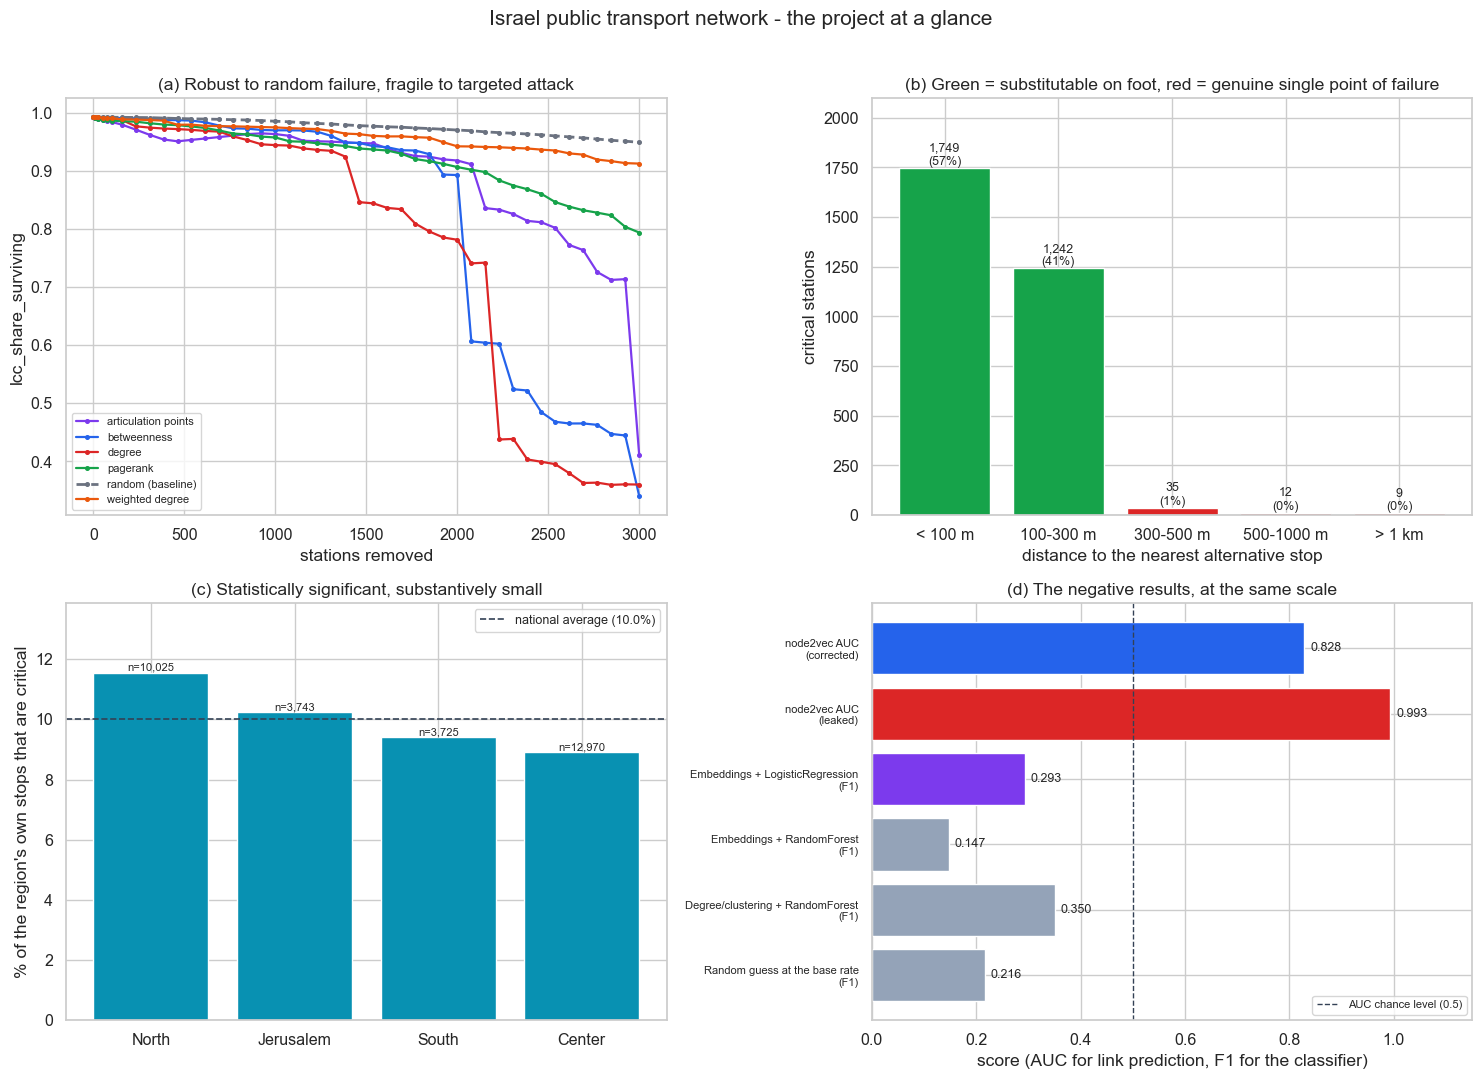

saved -> C:\Users\Sean-PC\Desktop\LAST SEMESTER\אלגוריתמים ברשתות\פרויקט גמר\outputs\nb\24_conclusions\figures\project_at_a_glance.png


In [27]:
# --- Figure 2: project at a glance ----------------------------------------
def _unavailable(ax, message):
    """Blank out a panel with an explanation instead of dropping it silently."""
    ax.text(0.5, 0.5, message, ha='center', va='center', fontsize=11,
            color='#64748b', wrap=True, transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)


fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# ---- (a) resilience curves
ax = axes[0][0]
if disruption is None or not len(disruption):
    _unavailable(ax, '(a) Resilience curves\n\nstage 06 not available')
else:
    s_col = pick_col(disruption, 'strategy')
    r_col = pick_col(disruption, 'removed')
    y_col = pick_col(disruption, 'lcc_share_surviving', 'lcc_share_original', 'lcc_share')
    palette = {'degree': '#dc2626', 'weighted degree': '#ea580c', 'pagerank': '#16a34a',
               'betweenness': '#2563eb', 'articulation points': '#7c3aed',
               'random (baseline)': '#6b7280'}
    for strat, grp in disruption.groupby(s_col):
        grp = grp.sort_values(r_col)
        is_random = 'random' in str(strat).lower()
        ax.plot(pd.to_numeric(grp[r_col], errors='coerce'),
                pd.to_numeric(grp[y_col], errors='coerce'),
                label=str(strat), linewidth=2.0 if is_random else 1.6,
                linestyle='--' if is_random else '-',
                color=palette.get(str(strat), None), marker='o', markersize=2.6)
    ax.set_xlabel('stations removed')
    ax.set_ylabel(y_col)
    ax.set_title('(a) Robust to random failure, fragile to targeted attack')
    ax.legend(fontsize=8, loc='lower left')

# ---- (b) substitutability
ax = axes[0][1]
if iso_summary is None or not len(iso_summary):
    _unavailable(ax, '(b) Substitutability of critical stations\n\nstage 05 not available')
else:
    b_col = pick_col(iso_summary, 'distance_band')
    n_col = pick_col(iso_summary, 'n_critical_stops', 'n_stops', 'count')
    v_col = pick_col(iso_summary, 'verdict')
    counts = pd.to_numeric(iso_summary[n_col], errors='coerce').fillna(0)
    if v_col is not None:
        colors = ['#dc2626' if 'isolat' in str(v).lower() else '#16a34a'
                  for v in iso_summary[v_col]]
    else:
        colors = ['#2563eb'] * len(iso_summary)
    bars = ax.bar(iso_summary[b_col].astype(str), counts, color=colors, edgecolor='white')
    total = float(counts.sum()) or 1.0
    for bar, v in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                format(int(v), ',') + '\n(' + format(100 * v / total, '.0f') + '%)',
                ha='center', va='bottom', fontsize=9)
    ax.margins(y=0.20)
    ax.set_xlabel('distance to the nearest alternative stop')
    ax.set_ylabel('critical stations')
    ax.set_title('(b) Green = within 300 m, red = no nearby stop within 300 m')

# ---- (c) regional criticality
ax = axes[1][0]
if regional is None or not len(regional):
    _unavailable(ax, '(c) Criticality by region\n\nstage 07 not available')
else:
    reg_col = pick_col(regional, 'region')
    pct_col = pick_col(regional, 'pct_critical')
    tot_col = pick_col(regional, 'total_stops')
    crit_col = pick_col(regional, 'critical_stops')
    order = regional.sort_values(pct_col, ascending=False)
    bars = ax.bar(order[reg_col].astype(str),
                  pd.to_numeric(order[pct_col], errors='coerce'),
                  color='#0891b2', edgecolor='white')
    if tot_col and crit_col:
        nat = (100 * pd.to_numeric(regional[crit_col], errors='coerce').sum()
               / max(1.0, float(pd.to_numeric(regional[tot_col], errors='coerce').sum())))
        ax.axhline(nat, color='#334155', ls='--', lw=1.2,
                   label='national average (' + format(nat, '.1f') + '%)')
        ax.legend(fontsize=9)
    if tot_col:
        for bar, n in zip(bars, pd.to_numeric(order[tot_col], errors='coerce')):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    'n=' + format(int(n), ','), ha='center', va='bottom', fontsize=8)
    ax.margins(y=0.20)
    ax.set_ylabel('% of the region\'s own stops that are critical')
    ax.set_title('(c) Statistically significant, substantively small')

# ---- (d) the negative results
ax = axes[1][1]
neg_labels, neg_values, neg_colors = [], [], []
if lp is not None and len(lp):
    m_col = pick_col(lp, 'method')
    p_col = pick_col(lp, 'protocol')
    a_col = pick_col(lp, 'auc')
    if m_col and p_col and a_col:
        n2v = lp[lp[m_col].astype(str).str.contains('node2vec', case=False)]
        for _, r in n2v.iterrows():
            leaked = 'leak' in str(r[p_col]).lower()
            neg_labels.append('node2vec AUC\n(' + str(r[p_col]) + ')')
            neg_values.append(float(r[a_col]))
            neg_colors.append('#dc2626' if leaked else '#2563eb')
if clf is not None and len(clf):
    mo_col = pick_col(clf, 'model')
    f_col = pick_col(clf, 'f1_critical', 'f1')
    if mo_col and f_col:
        for _, r in clf.iterrows():
            is_base = bool(re.search('all-positive|always critical|baseline',
                                     str(r[mo_col]), re.I))
            neg_labels.append(str(r[mo_col])[:40] + '\n(F1)')
            neg_values.append(float(r[f_col]))
            neg_colors.append('#94a3b8' if is_base else '#7c3aed')

if not neg_labels:
    _unavailable(ax, '(d) Negative results\n\nstage 13 not available')
else:
    y = np.arange(len(neg_labels))
    ax.barh(y, neg_values, color=neg_colors, edgecolor='white')
    for yi, v in zip(y, neg_values):
        ax.text(v + 0.012, yi, format(v, '.3f'), va='center', fontsize=9)
    ax.axvline(0.5, color='#334155', ls='--', lw=1.0, label='AUC chance level (0.5)')
    ax.set_yticks(y)
    ax.set_yticklabels(neg_labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.15)
    ax.set_xlabel('score (AUC for link prediction, F1 for the classifier)')
    ax.set_title('(d) The negative results, at the same scale')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Israel public transport network - the project at a glance', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(FIGURES / 'project_at_a_glance.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()
print('saved ->', FIGURES / 'project_at_a_glance.png')

## 26. My synthesis notes

These are the conclusions I would carry forward from the current run.

1. **Scheduled service volume is not a substitute for structural importance.** Weighted degree versus betweenness has rho `0.187`; their top-50 lists share four stations, and their top-10 lists share none. Plain degree relates more strongly to betweenness (`0.514`), but still does not identify the same extremes.

2. **The network is robust to random failure and more exposed to targeted removal, but realistic early damage is modest.** The surviving-normalized AUC is `0.9760` for random removal and `0.7655` for the most damaging degree order. After only 50 removals, the largest component still contains between 98.77% and 99.24% of surviving stations across the tested strategies. The long-run AUC gap is real; it should not be described as immediate collapse.

3. **Strict failure points are a minority.** Articulation stations are 2.95% of nodes and bridges 1.88% of edges. Among the 3,047 top-betweenness stations tested for a nearby stop, only 56 (1.8%) are beyond 300 m. That is good spatial redundancy, but still an upper bound on functional substitutability because route destinations and hours are ignored.

4. **Region has a small association with top-betweenness status.** North is highest at 11.55% and Center lowest at 8.91%, with a 2.64-point spread and Cramer's V `0.0387`. Jerusalem stands out more on articulation and bridge rates. I should not reduce this to a simple center-versus-periphery claim.

5. **The socioeconomic result is weak nationally and mixed locally.** National neighborhood rho is `-0.151`; community-level rho is `-0.182` and nonsignificant; within-community estimates range from `-0.691` to `+0.431`, with eight of 57 surviving BH. Aggregation hides different local relationships, but most community-specific estimates do not survive correction.

6. **Louvain finds strong weighted community structure, but membership and count are configuration-dependent.** The run printed above has high modularity and only about 7% cross-community edges. Seed and resolution checks belong beside any community count, and an ARI around the high 0.7s is broad similarity rather than identical membership.

7. **No simple random model reproduces the observed combination.** The configuration graph matches degrees but loses the real clustering; Erdős-Rényi has much shorter paths and almost no clustering; preferential attachment creates hubs that are too extreme; the rewired ring overclusters and has very long paths. Geography is a plausible missing mechanism, but it is not directly tested by these four null models.

8. **Rail and the minor modes need separate interpretation.** Heavy rail has 67 stations and 14 articulation points; its worst exact closure leaves 50% of surviving stations together. Light rail is far more path-like: 128 of 138 stations are articulation points and its largest component contains 25.36%. Neither should be summarized by the bus-dominated national average.

9. **The rail socioeconomic data supports no detected effect, not a fairness claim.** Only 12 cluster-based correlations are estimable because the continuous index is missing. None has raw `p < 0.05`; the strongest is rho `-0.267`, `p = 0.079`, on 44 exact-polygon stations.

10. **The embedding experiments do not show a distinct advantage here.** Correcting leakage reduces Node2vec link-prediction AUC to `0.8284`, slightly below CCPA at `0.8351`; hard negatives are poor; suggested links change simulated resilience by at most `0.011%`; and a simple degree/clustering classifier beats the embedding classifiers in the saved table.

11. **Hop count materially changes the routing question.** Only 0.33% of 300 sampled pairs use the same hop-optimal and time-optimal path. Hop routing adds a median 2,443.5 seconds, and travel-time versus hop betweenness has rho `0.6100` against a hop-resampling floor of `0.9558`. The hop-based criticality results remain valid for hop distance, not travel time.

12. **Criticality changes with time of day and population weighting.** The night graph has 14.0% fewer stations than midday, peak-versus-night betweenness rho is `0.6604` against a same-window floor of `0.9597`, and 4,224 morning-peak stations are absent at night. Population weighting also moves ranks well beyond its uniform control, but it remains a residential-population proxy rather than ridership.

13. **Sampled rerouting and topology rank stations differently.** The median modeled detour is 76.5 seconds and only four of 6,595 affected pairs become unreachable. Topological versus closure-cost rank has rho `0.1921`, `p = 0.327`, over 28 candidates. That is suggestive disagreement on a small selected sample, not proof that topology and travel cost are unrelated.

14. **“Critical” always needs its definition attached.** Across seven lenses, mean pairwise rho is `0.2096`; betweenness and service volume share four top-50 stations, and service volume and articulation severity share none. Of 231 stations flagged by at least one lens, 171 are single-lens flags and 60 have support from two or more. The cross-lens shortlist is the strongest common core, while single-lens stations remain relevant to their specific failure mode.

## 27. Limits I need to keep attached to the findings

1. **Sampled betweenness.** Notebook 04 uses 300 source stations, about 1% of the largest component. The two-seed top-50 overlap is 84%, but the p90-flag Jaccard is only 0.5296, so the head is more stable than the threshold boundary.
2. **Scheduled supply, not observed demand.** Edge weights are GTFS trip records. They are not boardings, occupancy, cancellations, or delivered service, and encoding conventions can affect comparisons across agencies.
3. **Split platforms.** Each `stop_id` is a node. Bays or platforms in one interchange can appear as separate low-degree nodes and can create artificial cut structures. Consolidating `parent_station` is a high-priority sensitivity test.
4. **Coarse region labels.** The broad regions come from coordinate rules rather than official boundaries. The CBS socioeconomic join uses polygons and should not be confused with this regional classification.
5. **Spatial substitution only.** A stop within 300 m may have the wrong line, direction, hours, or capacity. The measured 1.8% isolation share is a lower bound on functional isolation.
6. **Hop distance versus actual journeys.** Travel-time weighting changes paths and centrality substantially, but even that model omits waiting time, headways, transfer penalties, fares, and walking.
7. **Simulated node deletion.** Largest-component share is a topology measure, not a forecast of passengers affected. Real disruptions can be partial and can trigger replacement service or behavioral adaptation.
8. **Small and missing rail socioeconomic data.** The rail sample has 67 stations, only 44 exact polygon matches, and no continuous index values. Only 12 cluster-based tests are valid; the finite-only BH correction is usable, but its smallest q-value is about 0.615 and the sample remains underpowered.
9. **Stochastic communities.** Louvain count and membership depend on seed, resolution, backend, weighting, and graph scope. The sensitivity table is part of the result.
10. **One GTFS snapshot.** Seasonal schedules, network changes, feed errors, and real-time operations are not tested against a second period.
11. **Chosen population-proxy parameters.** The 500 m catchment, 250 m decay length, and service exponent 0.5 are assumptions. Stops without a CBS unit or population get zero/floor weights.
12. **Coarse time windows.** Five non-overlapping windows hide variation inside each block and treat boundary departures awkwardly. Night spans seven hours.
13. **Small selected rerouting sample.** Notebook 22 tests 30 candidates and sampled origin-destination pairs, with a fixed unreachability penalty. Its nonsignificant rank correlation has wide uncertainty.
14. **Unequal lens coverage.** Full-network and narrow conditional lenses are combined in the same synthesis. Coverage and candidate selection partly determine pairwise overlap, especially for the 30-station closure lens.
15. **No intervention cost or failure probability.** The shortlist counts ranking agreement. It does not optimize a budget or estimate which station is likely to fail.

## 28. What I would do next

In roughly the order I think would change the conclusions most:

1. Consolidate platforms and bays using `parent_station`, with spatial clustering as a fallback, then rerun topology and criticality.
2. Normalize edge weights to service on a representative weekday using `calendar.txt` and `calendar_dates.txt`.
3. Replace coordinate-band regions with official municipal and district polygons.
4. Redefine a walking alternative by shared useful destinations, frequency, hours, and direction rather than distance alone.
5. Build a time-dependent graph that includes waiting and transfer penalties, not just median in-vehicle segment time.
6. Validate population-weighted and structural rankings against smartcard, boarding, occupancy, or observed disruption data.
7. Compute exact betweenness in a faster implementation or add uncertainty bounds to the sampled ranking.
8. Build explicit walkable transfer edges between mode layers with a transfer cost.
9. Formulate edge addition as a resilience optimization problem and compare it with random and degree-based interventions.
10. Choose a concrete decision objective—such as expected lost travel time under a protection budget—and score every lens against it.
11. Rerun on another Israeli snapshot and a comparable national feed to separate stable structure from snapshot-specific behavior.

## 29. How I rerun the notebook chain

The safest order is numeric because each stage reads saved outputs from the stages it depends on:

| notebooks | role |
| --- | --- |
| 00-02 | inspect and prepare GTFS, then build the merged graph |
| 03-10 | topology, centrality, isolation, robustness, geography, communities, socioeconomic analysis, and null models |
| 11-12 | heavy rail and its socioeconomic join |
| 13 | graph-learning experiments |
| 14-17 | per-mode graphs and transfer inventory |
| 18-20 | travel-time and time-window graphs |
| 21-22 | population-weighted centrality and closure rerouting |
| 23 | compare criticality lenses |
| 24 | read the saved outputs and rebuild this synthesis |

Each notebook writes only to its own folder under `outputs/nb`. The large `stop_times.txt` input is needed by the graph-building stages, while most analytical stages consume saved CSV/JSON tables. Randomized stages keep explicit seeds, but Louvain and sampled rankings should still be described with their settings and stability checks. This notebook supports partial runs: the availability audit lists missing stages and later sections skip them.

## Conclusions

My main takeaways from this run are:

- The merged graph is highly connected overall, but targeted station choices damage it more than random failures.
- Scheduled service volume and structural importance are weakly related at the top: rho is `0.187`, with four shared stations in the two top-50 lists.
- Nearby-stop redundancy is high under the simple distance test—only 56 of 3,047 tested critical stations are beyond 300 m—but functional substitution remains unmeasured.
- Regional top-betweenness differences span only 2.64 percentage points and have negligible Cramer's V.
- Socioeconomic service relationships are weak nationally, mixed by community, and mostly nonsignificant after correction.
- Heavy rail has specific severe cut stations; light rail is structurally path-like; the bus graph dominates the merged national topology.
- Hop distance, service window, and population weighting each change the criticality ranking enough that they cannot be treated as minor implementation details.
- The graph-learning stage does not establish an embedding-specific advantage, and the rail socioeconomic stage does not detect an effect.
- The closure model suggests mostly short detours, but its candidate set is too small to establish how closure cost relates to topology.
- Across seven lenses, average agreement is low and 74% of flagged stations are flagged by exactly one lens.

So I should never write “the most critical station” without saying critical by which outcome: scheduled volume, shortest-path brokerage, disconnection severity, lack of a nearby stop, population weighting, peak-hour structure, or modeled rerouting cost. The 40-station cross-lens shortlist is the most defensible common set from this workflow, but it is still conditional on one scheduled GTFS snapshot, sampled metrics, unequal lens coverage, and no observed passengers.